In [1]:
import pandas as pd

df = pd.DataFrame({
    "age": [22, 25, 47, 52, 46, 56, 23, 40, 60, 36, 28, 33],
    "salary": [15000, 18000, 52000, 60000, 58000, 62000, 20000, 50000, 70000, 45000, 30000, 38000],
    "experience": [1, 2, 20, 25, 22, 30, 1, 15, 35, 10, 3, 7],
    "city_tier": [3, 2, 1, 1, 1, 1, 3, 2, 1, 2, 3, 2],
    "owns_house": [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1],
    "target": [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1]
})


from cherrypick.preprocessing import Preprocessor

preprocessor = Preprocessor(df)


In [2]:
df

,age,salary,experience,city_tier,owns_house,target
0,22,15000,1,3,0,0
1,25,18000,2,2,0,0
2,47,52000,20,1,1,1
3,52,60000,25,1,1,1
4,46,58000,22,1,1,1
5,56,62000,30,1,1,1
6,23,20000,1,3,0,0
7,40,50000,15,2,1,1
8,60,70000,35,1,1,1
9,36,45000,10,2,0,0


In [3]:
train, test = preprocessor.splitter(target='target', test_size=0.20)

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (9, 5)
Independent Feature = (9,)
Test dataset :

Dependent feature = (3, 5)
Independent Feature = (3,)


In [4]:
from cherrypick.anomaly import OutlierPruner

pruner = OutlierPruner(df = df, col='salary', method='iqr', keep=False)
df = pruner.remove_outlier()


In [5]:
df

,age,salary,experience,city_tier,owns_house,target
0,22,15000,1,3,0,0
1,25,18000,2,2,0,0
2,47,52000,20,1,1,1
3,52,60000,25,1,1,1
4,46,58000,22,1,1,1
5,56,62000,30,1,1,1
6,23,20000,1,3,0,0
7,40,50000,15,2,1,1
8,60,70000,35,1,1,1
9,36,45000,10,2,0,0


In [ ]:
orch.critique(cv=5)

NameError: name 'orch' is not defined

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

In [ ]:
import numpy as np

In [ ]:
lof = LocalOutlierFactor(n_jobs=-1, n_neighbors=20, algorithm='kd_tree', novelty=True)
X = df.select_dtypes(include = np.number)
labels = lof.fit(X)

In [ ]:
labels.predict(X)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
from scipy.stats import zscore
df = pd.DataFrame({
    'Age' : [-155,0,1,2,3,12,11,10,13,14,1000,2000,122]
})
z = zscore(df['Age']).abs()
df[df['Age'] > 2]

,Age
4,3
5,12
6,11
7,10
8,13
9,14
10,1000
11,2000
12,122


In [ ]:
def moddedzscore(df = df, col= 'Age', keep=True):
        df1=df.copy()
        median = np.median(df1[col])
        mad = np.median(np.abs(df1[col]-median))
        
        mod_zscore = 0.6745 * (df1[col] - median)/mad

        normal_data = df1[mod_zscore.abs() < 3]
        outliers = df1[mod_zscore.abs() > 3]

        DF_CONFIG = {
                True : normal_data,
                False : outliers
        }
        
        return DF_CONFIG[keep]
moddedzscore(df=df, col='Age')

,Age
1,0
2,1
3,2
4,3
5,12
6,11
7,10
8,13
9,14


In [ ]:

file = 'something.csv'
ext = file.split('.')[-1]
model = { 
    'csv' : "yo its working",
    file.endswith('xlsc') : "working",
    file.endswith('....csv') : "yo still working",
}
model[ext]
# model[ext]

'yo its working'

In [ ]:
file.endswith(ext)

True

In [ ]:
ext

'csv'

In [ ]:
def dataloader(file:str,  **kwargs):
    try:
        ext = file.split('.')[-1].lower()
        EXTENTION_CONFIG = {
            'csv' : pd.read_csv,
            'json':pd.read_json
            
        }
        loader = EXTENTION_CONFIG[ext]

        return loader(file, **kwargs)
    except Exception as err:
        raise ValueError(f"{err}")
    
dataloader(file = 'app.csv', sep='|')

,"name,age;city"
0,"krish,20;blr"
1,"yo,10;""i am, coder"""


In [ ]:
import csv

with open('app.csv', 'r') as f:
    sample = f.read(2048)
    f.seek(0)
    dialect = csv.Sniffer().sniff(sample)
    sep = dialect.delimiter
    print(sep)
    

;


In [ ]:
import pandas as pd 
import csv
import os

def dataloader(file:str, **kwargs):
    try:
        ext = file.split('.')[-1].lower()
        EXTENTION_CONFIG = {
            'csv' : pd.read_csv,
            'xlsx':pd.read_excel,
            'html' : pd.read_html,
            'json' : pd.read_json,
            'pkl': pd.read_pickle 
            
        }

        loader = EXTENTION_CONFIG.get(ext)

        if ext == 'csv':
            with open(file, 'r') as f:
                sample = f.read(2048)
                dialect = csv.Sniffer().sniff(sample)
                sep = dialect.delimiter

            return loader(file, sep=sep, **kwargs)
    
    


        return loader(file, **kwargs)
    
    except Exception as error:
        raise ValueError(f"Unsupported file format {error}{sep}")

In [ ]:
# dataloader('app.csv', sep=sep)

In [ ]:
dialect = csv.Sniffer().sniff(sample)
main_sep = dialect.delimiter

other_delims = [',', ';', '\t', '|']
other_delims.remove(main_sep)

for d in other_delims:
    content = sample.replace(d, main_sep)

In [ ]:
with open('app.csv', 'r') as f:
    print(f.read(2048))

name,age;city
krish,20;blr
yo,10;"i am, coder"


In [ ]:
dict1 = {}
for i in range(2):
    dic = dict(
        model = "RandomForest",
        accuracy = 90.8,
        f1score = 80.79
    )
    dic = dict(
            model = "Decision",
        accuracy = 90,
        f1score = 70.79

    )

    dict1['model'] = dic 

In [ ]:
dict1

{'model': {'model': 'Decision', 'accuracy': 90, 'f1score': 70.79}}

In [9]:
import pandas as pd
import numpy as np
import joblib
import logging as log
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.decomposition import PCA, TruncatedSVD
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (
                            RandomForestClassifier, RandomForestRegressor,
                            AdaBoostClassifier, AdaBoostRegressor,
                            GradientBoostingClassifier, GradientBoostingRegressor,
                            IsolationForest
                            )
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, r2_score, mean_squared_error, mean_absolute_error

In [10]:

classification_models = dict(

            LogisticRegression = LogisticRegression(),
            SVC = SVC(),
            KNeighborsClassifier = KNeighborsClassifier(),
            RandomForestClassifier = RandomForestClassifier(),
            DecisionTreeClassifier = DecisionTreeClassifier(),
            XGBClassifier = XGBClassifier(),
            AdaBoostClassifier = AdaBoostClassifier(),
            GradientBoostingClassifier = GradientBoostingClassifier()
)

In [11]:
import pandas as pd

df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 16, 35, 29],
    "target":     [0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2]
})
X = df.drop(columns='target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
model_data_classify = {}
for name, model in classification_models.items():
            if name not in ["LogisticRegression", "SVC", "KNeighborsClassifier"]:

                            estimator = model.fit(X_train, y_train)
                            y_pred = estimator.predict(X_test)

                            accuracyscore = accuracy_score(y_test, y_pred)
                            precisionscore = precision_score(y_test, y_pred, average='weighted')
                            recallscore = recall_score(y_test, y_pred, average='weighted')
                            f1scores = f1_score(y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            model_data_classify[name] = result
                            
            else:
                            scaler = StandardScaler()
                            X_train_scaled = scaler.fit_transform(X_train)
                            X_test_scaled = scaler.transform(X_test)

                            estimator = model.fit(X_train_scaled, y_train)
                            y_pred = estimator.predict(X_test_scaled)

                            accuracyscore = accuracy_score(y_test, y_pred)
                            precisionscore = precision_score(y_test, y_pred, average='weighted')
                            recallscore = recall_score(y_test, y_pred, average='weighted')
                            f1scores = f1_score(y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            model_data_classify[name] = result
                            # joblib.dump(scaler, f'{file_dir}/scaler.pkl')

In [14]:
model = pd.DataFrame(model_data_classify).T


In [15]:
lead = model.reset_index(drop=True).sort_values(by='f1score')
lead

,estimator,accuracy,precision,recall,f1score
0,LogisticRegression(),1.0,1.0,1.0,1.0
1,SVC(),1.0,1.0,1.0,1.0
2,KNeighborsClassifier(),1.0,1.0,1.0,1.0
3,"(DecisionTreeClassifier(max_features='sqrt', r...",1.0,1.0,1.0,1.0
4,DecisionTreeClassifier(),1.0,1.0,1.0,1.0
5,"XGBClassifier(base_score=None, booster=None, c...",1.0,1.0,1.0,1.0
6,"(DecisionTreeClassifier(max_depth=1, random_st...",1.0,1.0,1.0,1.0
7,([DecisionTreeRegressor(criterion='friedman_ms...,1.0,1.0,1.0,1.0


In [16]:
lead['estimator'].iloc[0]

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
lead[lead['accuracy'] >= 0.8]

,estimator,accuracy,precision,recall,f1score
0,LogisticRegression(),1.0,1.0,1.0,1.0
1,SVC(),1.0,1.0,1.0,1.0
2,KNeighborsClassifier(),1.0,1.0,1.0,1.0
3,"(DecisionTreeClassifier(max_features='sqrt', r...",1.0,1.0,1.0,1.0
4,DecisionTreeClassifier(),1.0,1.0,1.0,1.0
5,"XGBClassifier(base_score=None, booster=None, c...",1.0,1.0,1.0,1.0
6,"(DecisionTreeClassifier(max_depth=1, random_st...",1.0,1.0,1.0,1.0
7,([DecisionTreeRegressor(criterion='friedman_ms...,1.0,1.0,1.0,1.0


In [18]:
y_test

9     0
11    1
0     0
Name: target, dtype: int64

In [19]:
len(df['target'].value_counts())

3

In [20]:
thresh = 10

if thresh is not None:
    print(True)

True


In [21]:
a,b =1, 2
a


1

In [22]:
from cherrypick.orchestrator import Orchestrator

orch = Orchestrator(train=(X_train, y_train), test=(X_test, y_test), problem_statement='classification', file_dir='model')

In [23]:
orch.orchestrate()

-------------Demographics-------------
Best Model : LogisticRegression(f1score)
LogisticRegression Accuracy : 1.0
LogisticRegression Precision : 1.0
LogisticRegression Recall : 1.0
LogisticRegression f1score : 1.0
---------------------------------------


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
orch.critique()

With Relative Overfitting Gap = -0.8782608695652173, good to go for predictions!


In [25]:
orch.best_model

[LogisticRegression()]

In [26]:
df = orch.topkmodel()

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════════════════════════════════════════════╤══════════╤═══════════╤════════╤═════════╗ │
│ ║ Rank │                         estimator                          │ accuracy │ precision │ recall │ f1score ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥇1  │                    LogisticRegression()                    │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥈2  │                           SVC()                            │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥉3  │                   KNeighborsClassifier()                   │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  4   │                  RandomForestClassifier()                  │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  5   │                  DecisionTreeClassifier()                  │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  6   │        XGBClassifier(base_score=None, booster=None,        │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ║      │                      callbacks=None,                       │          │           │        │         ║ │
│ ║      │                         colsample_bylevel=None,            │          │           │        │         ║ │
│ ║      │                   colsample_bynode=None,                   │          │           │        │         ║ │
│ ║      │                   colsample_bytree=None, device=None,      │          │           │        │         ║ │
│ ║      │                early_stopping_rounds=None,                 │          │           │        │         ║ │
│ ║      │               enable_categorical=False, eval_metric=None,  │          │           │        │         ║ │
│ ║      │                    feature_types=None,                     │          │           │        │         ║ │
│ ║      │                    feature_weights=None, gamma=None,       │          │           │        │         ║ │
│ ║      │                     grow_policy=None,                      │          │           │        │         ║ │
│ ║      │                          importance_type=None,             │          │           │        │         ║ │
│ ║      │               interaction_constraints=None,                │          │           │        │         ║ │
│ ║      │                    learning_rate=None, max_bin=None,       │          │           │        │         ║ │
│ ║      │                  max_cat_threshold=None,                   │          │           │        │         ║ │
│ ║      │               max_cat_to_onehot=None, max_delta_step=None, │          │           │        │         ║ │
│ ║      │                      max_depth=None,                       │          │           │        │         ║ │
│ ║      │                 max_leaves=None, min_child_weight=None,    │          │           │        │         ║ │
│ ║      │                        missing=nan,                        │          │           │        │         ║ │
│ ║      │                        monotone_constraints=None,          │          │           │        │         ║ │
│ ║      │          multi_strategy=None, n_estimators=None,

In [ ]:
# import pandas as pd
# import time
# import numpy as np
# import joblib
# import logging as log
# from rich.console import Console
# from rich.table import Table
# from rich.progress import Progress, SpinnerColumn, TextColumn, TimeElapsedColumn
# from rich.panel import Panel
# from rich import box
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression, LogisticRegression
# from sklearn.svm import SVC, SVR
# from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
# from sklearn.ensemble import (
#     RandomForestClassifier, RandomForestRegressor,
#     AdaBoostClassifier, AdaBoostRegressor,
#     GradientBoostingClassifier, GradientBoostingRegressor
# )
# from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# from xgboost import XGBClassifier, XGBRegressor
# from sklearn.metrics import (
#     f1_score, recall_score, precision_score, accuracy_score,
#     r2_score, mean_squared_error, mean_absolute_error
# )

# import warnings
# warnings.filterwarnings('ignore')


# class Orchestrator:

#     def __init__(self, train: tuple, test: tuple, file_dir: str,
#                  problem_statement: str, seed: int = 42,
#                  focus_classifier: str = 'f1score',
#                  focus_regressor: str = 'mse'):

#         self.X_train, self.y_train = train
#         self.X_test, self.y_test = test
#         self.seed = seed
#         self.file_dir = file_dir
#         self.problem_statement = problem_statement
#         self.focus_classifier = focus_classifier
#         self.focus_regressor = focus_regressor

#         self.best_model = []
#         self.model_data = {}
#         self.model_data_classify = {}

#     @property
#     def best_estimator(self):
#         if self.best_model:
#             return self.best_model[0]
#         else:
#             raise ValueError("No model trained yet")

#     def orchestrate(self):

#         regressor_models = {
#             "LinearRegression": LinearRegression(),
#             "RandomForestRegressor": RandomForestRegressor(),
#             "XgBoostRegressor": XGBRegressor(),
#             "SVR": SVR(),
#             "KNeighborsRegressor": KNeighborsRegressor(),
#             "DecisionTreeRegressor": DecisionTreeRegressor(),
#             "AdaboostRegressor": AdaBoostRegressor(),
#             "GradientBoostRegressor": GradientBoostingRegressor()
#         }

#         classification_models = dict(
#             LogisticRegression=LogisticRegression(),
#             SVC=SVC(),
#             KNeighborsClassifier=KNeighborsClassifier(),
#             RandomForestClassifier=RandomForestClassifier(),
#             DecisionTreeClassifier=DecisionTreeClassifier(),
#             XGBClassifier=XGBClassifier(),
#             AdaBoostClassifier=AdaBoostClassifier(),
#             GradientBoostingClassifier=GradientBoostingClassifier()
#         )

#         linear_model_regression = ['LinearRegression', "SVR", "KNeighborsRegressor"]

#         try:
#             with Progress(
#                 SpinnerColumn(style="bold bright_cyan"),
#                 TextColumn("[bold white]⚡ {task.description}"),
#                 TextColumn("[dim]({task.completed}/{task.total})"),
#                 TimeElapsedColumn(),
#             ) as progress:

#                 if self.problem_statement == 'regression':

#                     task = progress.add_task("Starting...", total=len(regressor_models))

#                     for name, model in regressor_models.items():

#                         progress.update(task, description=f"[bold cyan]{name}[/bold cyan] → training...")

#                         if name not in linear_model_regression:

#                             regressor = model.fit(self.X_train, self.y_train)
#                             y_pred = regressor.predict(self.X_test)

#                         else:
#                             scaler = StandardScaler()
#                             X_train_scaled = scaler.fit_transform(self.X_train)
#                             X_test_scaled = scaler.transform(self.X_test)

#                             regressor = model.fit(X_train_scaled, self.y_train)
#                             y_pred = regressor.predict(X_test_scaled)

#                             joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')

#                         accuracy = r2_score(self.y_test, y_pred)
#                         mae = mean_absolute_error(self.y_test, y_pred)
#                         mse = mean_squared_error(self.y_test, y_pred)
#                         rmse = mse ** 0.5

#                         self.model_data[name] = dict(
#                             estimator=regressor,
#                             accuracy=accuracy,
#                             mse=mse,
#                             mae=mae,
#                             rmse=rmse
#                         )

#                         progress.update(task, advance=1)
#                         time.sleep(0.1)  # ✅ delay for visibility

#                     # ✅ force final completion
#                     progress.update(task, completed=progress.tasks[0].total)
#                     time.sleep(0.1)

#                 elif self.problem_statement == 'classification':

#                     task = progress.add_task("Starting...", total=len(classification_models))

#                     for name, model in classification_models.items():

#                         progress.update(task, description=f"[bold cyan]{name}[/bold cyan] → training...")

#                         if name not in ["LogisticRegression", "SVC", "KNeighborsClassifier"]:

#                             estimator = model.fit(self.X_train, self.y_train)
#                             y_pred = estimator.predict(self.X_test)

#                         else:
#                             scaler = StandardScaler()
#                             X_train_scaled = scaler.fit_transform(self.X_train)
#                             X_test_scaled = scaler.transform(self.X_test)

#                             estimator = model.fit(X_train_scaled, self.y_train)
#                             y_pred = estimator.predict(X_test_scaled)

#                             joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')

#                         self.model_data_classify[name] = dict(
#                             estimator=estimator,
#                             accuracy=accuracy_score(self.y_test, y_pred),
#                             precision=precision_score(self.y_test, y_pred, average='weighted'),
#                             recall=recall_score(self.y_test, y_pred, average='weighted'),
#                             f1score=f1_score(self.y_test, y_pred, average='weighted')
#                         )

#                         progress.update(task, advance=1)
#                         time.sleep(0.1)  # ✅ delay

#                     # ✅ force final completion
#                     progress.update(task, completed=progress.tasks[0].total)
#                     time.sleep(0.1)

#             # -------- RESULT -------- #

#             if self.problem_statement == 'regression':

#                 best_model = max(
#                     self.model_data,
#                     key=lambda m: self.model_data[m]["accuracy"] - self.model_data[m][self.focus_regressor]
#                 )

#                 model_final = self.model_data[best_model]['estimator']
#                 self.best_model.append(model_final)
#                 joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')

#                 print("-------------Demographics-------------")
#                 print(f"Best Model : {best_model}")
#                 print(f"Accuracy : {self.model_data[best_model]['accuracy']}")
#                 print(f"{self.focus_regressor.upper()} : {self.model_data[best_model][self.focus_regressor]}")
#                 print("---------------------------------------")

#                 return model_final

#             elif self.problem_statement == 'classification':

#                 best_model = max(
#                     self.model_data_classify,
#                     key=lambda x: self.model_data_classify[x][self.focus_classifier]
#                 )

#                 model_final = self.model_data_classify[best_model]['estimator']
#                 self.best_model.append(model_final)
#                 joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')

#                 print("-------------Demographics-------------")
#                 print(f"Best Model : {best_model}")
#                 print(f"Accuracy : {self.model_data_classify[best_model]['accuracy']}")
#                 print(f"Precision : {self.model_data_classify[best_model]['precision']}")
#                 print(f"Recall : {self.model_data_classify[best_model]['recall']}")
#                 print(f"F1Score : {self.model_data_classify[best_model]['f1score']}")
#                 print("---------------------------------------")

#                 return model_final

#         except Exception as error:
#             print(error)

In [ ]:
orch = Orchestrator(train=(X_train, y_train), test=(X_test, y_test), problem_statement='classification', file_dir='model')

In [ ]:
orch.orchestrate()

Output()

-------------Demographics-------------
Best Model : LogisticRegression
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1Score : 1.0
---------------------------------------


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:

import pandas as pd
import time
import numpy as np
import joblib
import logging as log
from rich.console import Console
from rich.table import Table
from rich.progress import Progress, SpinnerColumn, BarColumn, TextColumn, TimeElapsedColumn
from rich.panel import Panel
from rich import box
from rich.table import Table
from rich.console import Console
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.decomposition import PCA, TruncatedSVD
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (
                            RandomForestClassifier, RandomForestRegressor,
                            AdaBoostClassifier, AdaBoostRegressor,
                            GradientBoostingClassifier, GradientBoostingRegressor
                            )
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

class Orchestrator:

    def __init__(self, train: tuple, test:tuple, file_dir:str ,problem_statement : str, seed:int = 42, focus_classifier: str = 'f1score', focus_regressor:str = 'mse' ):
        self.X_train, self.y_train = train
        self.X_test, self.y_test = test
        self.seed = seed
        self.file_dir = file_dir
        self.problem_statement = problem_statement
        self.focus_classifier = focus_classifier
        self.focus_regressor = focus_regressor

        ##Model data and persistence  
        self.best_model = []
        self.model_data = {}
        self.model_data_classify = {}
    
    @property
    def best_estimator(self):
        if self.best_model[0]:
            return self.best_model[0]
        else:
            raise ValueError("No model trained yet, use orchestrate(problem_statement : str , focus_classifier: str = 'f1score', focus_regressor:str = 'mse') to access best performing model")
         

    def orchestrate(self):


        regressor_models = {
            "LinearRegression" : LinearRegression(),
            "RandomForestRegressor" : RandomForestRegressor(),
            "XgBoostRegressor" : XGBRegressor(),
            "SVR" : SVR(),
            "KNeighborsRegressor" : KNeighborsRegressor(),
            "DecisionTreeRegressor" : DecisionTreeRegressor(),
            "AdaboostRegressor": AdaBoostRegressor(),
            "GradientBoostRegressor" : GradientBoostingRegressor()
        }

        classification_models = dict(

            LogisticRegression = LogisticRegression(),
            SVC = SVC(),
            KNeighborsClassifier = KNeighborsClassifier(),
            RandomForestClassifier = RandomForestClassifier(),
            DecisionTreeClassifier = DecisionTreeClassifier(),
            XGBClassifier = XGBClassifier(),
            AdaBoostClassifier = AdaBoostClassifier(),
            GradientBoostingClassifier = GradientBoostingClassifier()

        )
        linear_model_regression = ['LinearRegression', "SVR", "KNeighborsRegressor"] 

        try:
            with Progress(
                SpinnerColumn(style="bold bright_cyan"),
                TextColumn("[red]{task.description}"),
                TextColumn("[dim]({task.completed}/{task.total})"),
                TimeElapsedColumn(),
            ) as progress:
                
                if self.problem_statement == 'regression':
                    task = progress.add_task("Starting...", total=len(regressor_models))
                    
                    for name, model in regressor_models.items():
                        if name not in linear_model_regression:
                            progress.update(task, description=f"[bold cyan]{name}[/bold cyan] → training...")

                            regressor = model.fit(self.X_train, self.y_train)
                            y_pred = regressor.predict(self.X_test)

                            accuracy = r2_score(self.y_test, y_pred)
                            mae = mean_absolute_error(self.y_test, y_pred)
                            mse = mean_squared_error(self.y_test, y_pred)
                            rmse = (mse) ** 0.5
                            adj_r2 = None ## will be soon applying Adjusted R2_score for the penalisation influence of the useless features.

                            result = dict(
                                estimator = regressor,
                                accuracy = accuracy,
                                mse=mse,
                                mae=mae,
                                rmse = rmse
                            )
                            self.model_data[name] = result
                            

                        else:
                            scaler = StandardScaler()
                            X_train_scaled = scaler.fit_transform(self.X_train)
                            X_test_scaled = scaler.transform(self.X_test)

                            ensemble = model.fit(X_train_scaled, self.y_train)
                            y_pred = ensemble.predict(X_test_scaled)

                            accuracy = r2_score(self.y_test, y_pred)
                            mae = mean_absolute_error(self.y_test, y_pred)
                            mse = mean_squared_error(self.y_test, y_pred)
                            rmse = (mse) ** 0.5

                            result = dict(
                                estimator = ensemble,
                                accuracy = accuracy,
                                mse=mse,
                                mae=mae,
                                rmse = rmse
                            )
                            self.model_data[name] = result
                            joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')
                            
                        progress.update(task, advance=1)
                        time.sleep(0.1)  # ✅ delay for visibility
                    progress.update(task, completed=progress.tasks[0].total)
                    time.sleep(0.1)

                if self.focus_regressor == "mse":
                    best_model = pd.DataFrame(self.model_data).T.sort_values(by=self.focus_regressor)['estimator'][0]
                    return best_model


                elif self.focus_regressor == "mae":
                    best_model = max(self.model_data, key=lambda m: self.model_data[m]["accuracy"] - self.model_data[m]["mae"])
                    model_final = self.model_data[best_model]['estimator']
                    self.best_model.append(model_final)
                    joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {best_model}")
                    print(f"{best_model} Accuracy(R2 SCore) : {self.model_data[best_model]['accuracy']}")
                    print(f"{best_model} MAE : {self.model_data[best_model]['mae']}")
                    print("---------------------------------------")
                    return model_final

                elif self.focus_regressor == "rmse":
                    best_model = max(self.model_data, key=lambda m: self.model_data[m]["accuracy"] - self.model_data[m]["rmse"])
                    model_final = self.model_data[best_model]['estimator']
                    self.best_model.append(model_final)
                    joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {best_model}")
                    print(f"{best_model} Accuracy(R2 SCore) : {self.model_data[best_model]['accuracy']}")
                    print(f"{best_model} RMSE : {self.model_data[best_model]['rmse']}")
                    print("---------------------------------------")
                    return model_final

            if self.problem_statement == 'classification':
                
                for name, model in classification_models.items():
                    if name not in ["LogisticRegression", "SVC", "KNeighborsClassifier"]:

                            estimator = model.fit(self.X_train, self.y_train)
                            y_pred = estimator.predict(self.X_test)

                            accuracyscore = accuracy_score(self.y_test, y_pred)
                            precisionscore = precision_score(self.y_test, y_pred, average='weighted')
                            recallscore = recall_score(self.y_test, y_pred, average='weighted')
                            f1scores = f1_score(self.y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            self.model_data_classify[name] = result
                            

                    else:
                            scaler = StandardScaler()
                            X_train_scaled = scaler.fit_transform(self.X_train)
                            X_test_scaled = scaler.transform(self.X_test)

                            estimator = model.fit(X_train_scaled, self.y_train)
                            y_pred = estimator.predict(X_test_scaled)

                            accuracyscore = accuracy_score(self.y_test, y_pred)
                            precisionscore = precision_score(self.y_test, y_pred, average='weighted')
                            recallscore = recall_score(self.y_test, y_pred, average='weighted')
                            f1scores = f1_score(self.y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            self.model_data_classify[name] = result
                            joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')
                            
                try:
                    if self.focus_classifier == 'precision':
                        best_model = pd.DataFrame(model_data_classify).sort_values(by='precision')['estimator'].iloc[0]
                        
                    elif self.focus_classifier == 'recall':
                            best_model = max(self.model_data_classify, key= lambda x: self.model_data_classify[x]['recall'])
                            model_final = self.model_data_classify[best_model]['estimator']
                            self.best_model.append(model_final)
                            joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')
                            print("-------------Demographics-------------")
                            print(f"Best Model : {best_model}({self.focus_classifier})")
                            print(f"{best_model} Accuracy : {self.model_data_classify[best_model]['accuracy']}")
                            print(f"{best_model} Precision : {self.model_data_classify[best_model]['precision']}")
                            print(f"{best_model} Recall : {self.model_data_classify[best_model]['recall']}")
                            print(f"{best_model} f1score : {self.model_data_classify[best_model]['f1score']}")
                            print('debug : ',best_model)
                            print("---------------------------------------")
                            return model_final 
                        
                    elif self.focus_classifier == 'f1score':
                            best_model = max(self.model_data_classify, key=lambda x: self.model_data_classify[x]['f1score'])
                            model_final = self.model_data_classify[best_model]['estimator']
                            self.best_model.append(model_final)
                            joblib.dump(model_final, f'{self.file_dir}/{best_model}.pkl')
                            print("-------------Demographics-------------")
                            print(f"Best Model : {best_model}")
                            print(f"{best_model} Accuracy : {self.model_data_classify[best_model]['accuracy']}")
                            print(f"{best_model} Precision : {self.model_data_classify[best_model]['precision']}")
                            print(f"{best_model} Recall : {self.model_data_classify[best_model]['recall']}")
                            print(f"{best_model} f1score : {self.model_data_classify[best_model]['f1score']}")
                            print('debug : ',best_model)
                            print("---------------------------------------")
                            return model_final
                        
                    else:
                        print("Invalid Metric Please consider Recall, Precision or F1_Score")
                except Exception as error:
                    print(f"{error}")

        except Exception as error:
            print(error)
                

    def cv(self, type_cv:str, param_grid : dict, scoring_type:str, n_jobs:int=-1, cv: int=5):
        try:
            if type_cv == 'randomised':
                random = RandomizedSearchCV(
                     estimator=self.best_model[0],
                     cv=cv,
                     param_distributions=param_grid,
                     scoring=scoring_type,
                     n_jobs=n_jobs,
                     refit=True
                    )
                
                random_cv_model = random.fit(self.X_train, self.y_train)
                best_param = random_cv_model.best_params_
                best_score = random_cv_model.best_score_
                best_model = random.best_estimator_

                result = dict(
                     best_params = best_param,
                     best_scores = best_score,
                     best_model = best_model                    
                )
                for keys, values in result.items():
                      print(f'{keys} : {values}')
                joblib.dump(result['best_model'], f'{self.file_dir}/{result['best_model']}.pkl')
                
                return result['best_model']


            elif type_cv == 'gridsearch':
                gridcv = GridSearchCV(
                      estimator=self.best_model[0],
                      cv = cv,
                      param_grid=param_grid,
                      scoring=scoring_type,
                      n_jobs=n_jobs,
                      refit=True
                 )
                gridcv_model = gridcv.fit(self.X_train, self.y_train)
                best_param = gridcv_model.best_params_
                best_score = gridcv_model.best_score_
                best_model = gridcv_model.best_estimator_

                result = dict(
                     best_params = best_param,
                     best_scores = best_score,
                     best_model = best_model                                        
                )
                for keys, values in result.items():
                      print(f'{keys} : {values}')
                joblib.dump(result['best_model'], f'{self.file_dir}/{result['best_model']}.pkl')

                return result['best_model']



            else:
                 print("Please enter the correct Cross Validation type") 


        except Exception as error:
             print(error)


    def critique(self, cv:int = 5, scoring:str='neg_mean_squared_error', topkmodel:int = None) -> str:
        try:
            scores = cross_val_score(self.best_model[0], cv=cv, X=self.X_train, y=self.y_train, scoring=scoring)
            mean_score_cv =  np.mean(scores)

            y_train_pred = self.best_model[0].predict(self.X_train)
            y_test_pred = self.best_model[0].predict(self.X_test)
            
            if scoring == "neg_mean_squared_error":

                ## Scores based upon
                mse_train = mean_squared_error(self.y_train, y_train_pred)

                ## Overfitting gap calculation
                overfitting_gap = mean_score_cv - mse_train
                relative_gap = overfitting_gap/mse_train

                if relative_gap < 0.05:
                    message =  "NO Overfitting"
                elif relative_gap < 0.15:
                    message =  "Mild Overfitting"
                elif relative_gap < 0.30:
                    message =  "HIGH Overfitting"
                elif relative_gap < 0:
                    message =  "Randomness"

                else:
                    pass
            
            if scoring == 'r2':
                r2_train = r2_score(self.y_train, y_train_pred)

                overfitting_gap = mean_score_cv - r2_train
                relative_gap = overfitting_gap / r2_train

                if relative_gap < 0.05:
                    message =  "NO Overfitting"
                elif relative_gap < 0.15:
                    message = "Mild Overfitting"
                elif relative_gap < 0.30:
                    message =  "HIGH Overfitting"
                elif relative_gap < 0:
                    message= "Randomness"

                else:
                    pass

            ALERT_CONFIG = {
                "NO Overfitting" : f"with Relative Overfitting Gap = {relative_gap}, good to go for predictions!",
                "Mild Overfitting" : f"with Relative Overfitting Gap = {relative_gap}, might need to train the model appropriately",
                "HIGH Overfitting" : f"With Relative Overfitting Gap = {relative_gap}, high chances of data leakage or dataset is too simple",
                "Randomness" : f'with Relative Overfitting Gap = {relative_gap}, might be data leakage or model randomness'
            }

            return ALERT_CONFIG[message]
                 
        except Exception as err:
             print(err)
            
            
    def topkmodel(self,access_estimator : int = None, threshold: float | int = None) -> pd.DataFrame | None:

        console = Console()

        if self.problem_statement == 'regression':
            metric = self.focus_regressor
            data = self.model_data
        else:
            metric = self.focus_classifier
            data = self.model_data_classify

        
        df = (
            pd.DataFrame(data)
            .T
            .reset_index(drop=True)
            .sort_values(by=metric, ascending=False)
        )

        df.index = range(1, len(df) + 1)
        df.insert(0, "Rank", df.index)

        if threshold is not None:
            df = df[df[metric] >= threshold]

        df = df.round(4)

       
        table = Table(
            title="  Model Arena",
            box=box.DOUBLE_EDGE,
            show_lines=True,
            header_style="bold magenta",
            border_style="bright_blue"
        )

        for col in df.columns:
            style = "bright_cyan" if col == "estimator" else "white"
            table.add_column(col, justify="center", style=style)

        
        for _, row in df.iterrows():

            values = []
            row_style = ""

            for col in df.columns:
                val = row[col]

                if col == "Rank":
                    if val == 1:
                        val = "[bold yellow]🥇1[/bold yellow]"
                        row_style = "bold yellow"
                    elif val == 2:
                        val = "[bold #C0C0C0]🥈2[/bold #C0C0C0]"
                        row_style = "#C0C0C0"
                    elif val == 3:
                        val = "[bold #CD7F32]🥉3[/bold #CD7F32]"
                        row_style = "#CD7F32"
                    else:
                        val = f"[white]{val}[/white]"

                elif isinstance(val, (int, float)):
                    if val >= 0.9:
                        val = f"[bright_green]{val}[/bright_green]"
                    elif val >= 0.75:
                        val = f"[yellow]{val}[/yellow]"
                    else:
                        val = f"[red]{val}[/red]"

                values.append(str(val))

            table.add_row(*values, style=row_style)

        panel = Panel.fit(
            table,
            title="[bold bright_cyan] Top Models",
            border_style="bright_magenta"
        )
        
        console.print(panel)

        if access_estimator is not None:
            return df['estimator'].iloc[access_estimator-1]
        
        else:
            None


In [ ]:
orch = Orchestrator(train=(X_train, y_train), test=(X_test, y_test), problem_statement='classification', file_dir='model')
orch.orchestrate()

Output()

max() iterable argument is empty


## Currently under work

In [ ]:

import pandas as pd
import time
import numpy as np
import joblib
import logging as log
from rich.console import Console
from rich.table import Table
from rich.progress import Progress, SpinnerColumn, BarColumn, TextColumn, TimeElapsedColumn
from rich.panel import Panel
from rich import box
from rich.table import Table
from rich.console import Console
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.decomposition import PCA, TruncatedSVD
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (
                            RandomForestClassifier, RandomForestRegressor,
                            AdaBoostClassifier, AdaBoostRegressor,
                            GradientBoostingClassifier, GradientBoostingRegressor
                            )
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

class Orchestrator:

    def __init__(self, train: tuple, test:tuple, file_dir:str ,problem_statement : str, seed:int = 42, focus_classifier: str = 'f1score', focus_regressor:str = 'mse' ):
        self.X_train, self.y_train = train
        self.X_test, self.y_test = test
        self.seed = seed
        self.file_dir = file_dir
        self.problem_statement = problem_statement
        self.focus_classifier = focus_classifier
        self.focus_regressor = focus_regressor

        ##Model data and persistence 
         
        self.best_model = []
        self.model_data = {}
        self.model_data_classify = {}
    
    @property
    def best_estimator(self):
        if self.best_model[0]:
            return self.best_model[0]
        else:
            raise ValueError("No model trained yet, use orchestrate(problem_statement : str , focus_classifier: str = 'f1score', focus_regressor:str = 'mse') to access best performing model")
         

    def orchestrate(self):


        regressor_models = {
            "LinearRegression" : LinearRegression(),
            "RandomForestRegressor" : RandomForestRegressor(),
            "XgBoostRegressor" : XGBRegressor(),
            "SVR" : SVR(),
            "KNeighborsRegressor" : KNeighborsRegressor(),
            "DecisionTreeRegressor" : DecisionTreeRegressor(),
            "AdaboostRegressor": AdaBoostRegressor(),
            "GradientBoostRegressor" : GradientBoostingRegressor()
        }

        classification_models = dict(

            LogisticRegression = LogisticRegression(),
            SVC = SVC(),
            KNeighborsClassifier = KNeighborsClassifier(),
            RandomForestClassifier = RandomForestClassifier(),
            DecisionTreeClassifier = DecisionTreeClassifier(),
            XGBClassifier = XGBClassifier(),
            AdaBoostClassifier = AdaBoostClassifier(),
            GradientBoostingClassifier = GradientBoostingClassifier()

        )
        linear_model_regression = ['LinearRegression', "SVR", "KNeighborsRegressor"] 

        try:
            if self.problem_statement == 'regression':
                for name, model in regressor_models.items():
                    if name not in linear_model_regression:

                        regressor = model.fit(self.X_train, self.y_train)
                        y_pred = regressor.predict(self.X_test)

                        accuracy = r2_score(self.y_test, y_pred)
                        mae = mean_absolute_error(self.y_test, y_pred)
                        mse = mean_squared_error(self.y_test, y_pred)
                        rmse = (mse) ** 0.5
                        adj_r2 = None ## will be soon applying Adjusted R2_score for the penalisation influence of the useless features.

                        result = dict(
                            estimator = regressor,
                            accuracy = accuracy,
                            mse=mse,
                            mae=mae,
                            rmse = rmse
                        )
                        self.model_data[name] = result
                        

                    else:
                        scaler = StandardScaler()
                        X_train_scaled = scaler.fit_transform(self.X_train)
                        X_test_scaled = scaler.transform(self.X_test)

                        ensemble = model.fit(X_train_scaled, self.y_train)
                        y_pred = ensemble.predict(X_test_scaled)

                        accuracy = r2_score(self.y_test, y_pred)
                        mae = mean_absolute_error(self.y_test, y_pred)
                        mse = mean_squared_error(self.y_test, y_pred)
                        rmse = (mse) ** 0.5
                        
                        result = dict(
                            estimator = ensemble,
                            accuracy = accuracy,
                            mse=mse,
                            mae=mae,
                            rmse = rmse
                        )
                        self.model_data[name] = result
                        joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')
                        

                if self.focus_regressor == "mse":
                    
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['mse', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} MSE : {data_metrics['mse'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model


                elif self.focus_regressor == "mae":
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['mae', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} MAE : {data_metrics['mae'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model

                elif self.focus_regressor == "rmse":
                    
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['rmse', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} RMSE : {data_metrics['rmse'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model

            if self.problem_statement == 'classification':
                
                for name, model in classification_models.items():
                    if name not in ["LogisticRegression", "SVC", "KNeighborsClassifier"]:

                            estimator = model.fit(self.X_train, self.y_train)
                            y_pred = estimator.predict(self.X_test)

                            accuracyscore = accuracy_score(self.y_test, y_pred)
                            precisionscore = precision_score(self.y_test, y_pred, average='weighted')
                            recallscore = recall_score(self.y_test, y_pred, average='weighted')
                            f1scores = f1_score(self.y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            self.model_data_classify[name] = result
                            

                    else:
                            scaler = StandardScaler()
                            X_train_scaled = scaler.fit_transform(self.X_train)
                            X_test_scaled = scaler.transform(self.X_test)

                            estimator = model.fit(X_train_scaled, self.y_train)
                            y_pred = estimator.predict(X_test_scaled)

                            accuracyscore = accuracy_score(self.y_test, y_pred)
                            precisionscore = precision_score(self.y_test, y_pred, average='weighted')
                            recallscore = recall_score(self.y_test, y_pred, average='weighted')
                            f1scores = f1_score(self.y_test, y_pred, average='weighted')

                            result = dict(
                                estimator = estimator,
                                accuracy = accuracyscore,
                                precision = precisionscore,
                                recall = recallscore,
                                f1score = f1scores
                            )
                            self.model_data_classify[name] = result
                            joblib.dump(scaler, f'{self.file_dir}/scaler.pkl')
                            
                try:
                    if self.focus_classifier == 'precision':
                            
                            data_metrics = pd.DataFrame(self.model_data_classify).T.sort_values(by='precision', ascending=False)
                            best_model = data_metrics['estimator'].iloc[0]
                            model_name = type(best_model).__name__
                        
                            self.best_model.append(best_model)
                            joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                            print("-------------Demographics-------------")
                            print(f"Best Model : {model_name}({self.focus_classifier})")
                            print(f"{model_name} Accuracy : {data_metrics['accuracy'].iloc[0]}")
                            print(f"{model_name} Precision : {data_metrics['precision'].iloc[0]}")
                            print(f"{model_name} Recall : {data_metrics['recall'].iloc[0]}")
                            print(f"{model_name} f1score : {data_metrics['f1score'].iloc[0]}")
                            print("---------------------------------------")
                            return best_model
                            
                        
                    elif self.focus_classifier == 'recall':
                            data_metrics = pd.DataFrame(self.model_data_classify).T.sort_values(by='recall', ascending=False)
                            best_model = data_metrics['estimator'].iloc[0]
                            model_name = type(best_model).__name__
                        
                            self.best_model.append(best_model)
                            joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                            print("-------------Demographics-------------")
                            print(f"Best Model : {model_name}({self.focus_classifier})")
                            print(f"{model_name} Accuracy : {data_metrics['accuracy'].iloc[0]}")
                            print(f"{model_name} Precision : {data_metrics['precision'].iloc[0]}")
                            print(f"{model_name} Recall : {data_metrics['recall'].iloc[0]}")
                            print(f"{model_name} f1score : {data_metrics['f1score'].iloc[0]}")
                            print("---------------------------------------")
                            return best_model
                        
                    elif self.focus_classifier == 'f1score':
                            data_metrics = pd.DataFrame(self.model_data_classify).T.sort_values(by='f1score', ascending=False)
                            best_model = data_metrics['estimator'].iloc[0]
                            model_name = type(best_model).__name__
                        
                            self.best_model.append(best_model)
                            joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                            print("-------------Demographics-------------")
                            print(f"Best Model : {model_name}({self.focus_classifier})")
                            print(f"{model_name} Accuracy : {data_metrics['accuracy'].iloc[0]}")
                            print(f"{model_name} Precision : {data_metrics['precision'].iloc[0]}")
                            print(f"{model_name} Recall : {data_metrics['recall'].iloc[0]}")
                            print(f"{model_name} f1score : {data_metrics['f1score'].iloc[0]}")
                            print("---------------------------------------")
                            return best_model
                        
                    else:
                        print("Invalid Metric Please consider Recall, Precision or F1_Score")
                except Exception as error:
                    print(f"{error}")

        except Exception as error:
            print(error)
                

    def cv(self, type_cv:str, param_grid : dict, scoring_type:str, n_jobs:int=-1, cv: int=5):
        try:
            if type_cv == 'randomised':
                random = RandomizedSearchCV(
                     estimator=self.best_model[0],
                     cv=cv,
                     param_distributions=param_grid,
                     scoring=scoring_type,
                     n_jobs=n_jobs,
                     refit=True
                    )
                
                random_cv_model = random.fit(self.X_train, self.y_train)
                best_param = random_cv_model.best_params_
                best_score = random_cv_model.best_score_
                best_model = random.best_estimator_

                result = dict(
                     best_params = best_param,
                     best_scores = best_score,
                     best_model = best_model                    
                )
                for keys, values in result.items():
                      print(f'{keys} : {values}')
                joblib.dump(result['best_model'], f'{self.file_dir}/{result['best_model']}.pkl')
                
                return result['best_model']


            elif type_cv == 'gridsearch':
                gridcv = GridSearchCV(
                      estimator=self.best_model[0],
                      cv = cv,
                      param_grid=param_grid,
                      scoring=scoring_type,
                      n_jobs=n_jobs,
                      refit=True
                 )
                gridcv_model = gridcv.fit(self.X_train, self.y_train)
                best_param = gridcv_model.best_params_
                best_score = gridcv_model.best_score_
                best_model = gridcv_model.best_estimator_

                result = dict(
                     best_params = best_param,
                     best_scores = best_score,
                     best_model = best_model                                        
                )
                for keys, values in result.items():
                      print(f'{keys} : {values}')
                joblib.dump(result['best_model'], f'{self.file_dir}/{result['best_model']}.pkl')

                return result['best_model']



            else:
                 print("Please enter the correct Cross Validation type") 


        except Exception as error:
             print(error)


    def critique(self, cv:int = 5, scoring:str='neg_mean_squared_error', topkmodel:int = None) -> str:
        try:
            scores = cross_val_score(self.best_model[0], cv=cv, X=self.X_train, y=self.y_train, scoring=scoring)
            mean_score_cv =  np.mean(scores)

            y_train_pred = self.best_model[0].predict(self.X_train)
            y_test_pred = self.best_model[0].predict(self.X_test)
            
            if scoring == "neg_mean_squared_error":

                ## Scores based upon
                mse_train = mean_squared_error(self.y_train, y_train_pred)

                ## Overfitting gap calculation
                overfitting_gap = mean_score_cv - mse_train
                relative_gap = overfitting_gap/mse_train

                if relative_gap < 0.05:
                    message =  "NO Overfitting"
                elif relative_gap < 0.15:
                    message =  "Mild Overfitting"
                elif relative_gap < 0.30:
                    message =  "HIGH Overfitting"
                elif relative_gap < 0:
                    message =  "Randomness"

                else:
                    pass
            
            if scoring == 'r2':
                r2_train = r2_score(self.y_train, y_train_pred)

                overfitting_gap = mean_score_cv - r2_train
                relative_gap = overfitting_gap / r2_train

                if relative_gap < 0.05:
                    message =  "NO Overfitting"
                elif relative_gap < 0.15:
                    message = "Mild Overfitting"
                elif relative_gap < 0.30:
                    message =  "HIGH Overfitting"
                elif relative_gap < 0:
                    message= "Randomness"

                else:
                    pass

            ALERT_CONFIG = {
                "NO Overfitting" : f"with Relative Overfitting Gap = {relative_gap}, good to go for predictions!",
                "Mild Overfitting" : f"with Relative Overfitting Gap = {relative_gap}, might need to train the model appropriately",
                "HIGH Overfitting" : f"With Relative Overfitting Gap = {relative_gap}, high chances of data leakage or dataset is too simple",
                "Randomness" : f'with Relative Overfitting Gap = {relative_gap}, might be data leakage or model randomness'
            }

            return ALERT_CONFIG[message]
                 
        except Exception as err:
             print(err)
            
            
    def topkmodel(self, access_estimator : int = None, threshold: float | int = None) -> pd.DataFrame | None:

        console = Console()

        if self.problem_statement == 'regression':
            metric = self.focus_regressor
            data = self.model_data
        else:
            metric = self.focus_classifier
            data = self.model_data_classify

        
        df = (
            pd.DataFrame(data)
            .T
            .reset_index(drop=True)
            .sort_values(by=metric, ascending=False)
        )

        df.index = range(1, len(df) + 1)
        df.insert(0, "Rank", df.index)

        if threshold is not None:
            df = df[df[metric] >= threshold]

        df = df.round(4)

       
        table = Table(
            title="  Model Arena",
            box=box.DOUBLE_EDGE,
            show_lines=True,
            header_style="bold magenta",
            border_style="bright_blue"
        )

        for col in df.columns:
            style = "bright_cyan" if col == "estimator" else "white"
            table.add_column(col, justify="center", style=style)

        
        for _, row in df.iterrows():

            values = []
            row_style = ""

            for col in df.columns:
                val = row[col]

                if col == "Rank":
                    if val == 1:
                        val = "[bold yellow]🥇1[/bold yellow]"
                        row_style = "bold yellow"
                    elif val == 2:
                        val = "[bold #C0C0C0]🥈2[/bold #C0C0C0]"
                        row_style = "#C0C0C0"
                    elif val == 3:
                        val = "[bold #CD7F32]🥉3[/bold #CD7F32]"
                        row_style = "#CD7F32"
                    else:
                        val = f"[white]{val}[/white]"

                elif isinstance(val, (int, float)):
                    if val >= 0.9:
                        val = f"[bright_green]{val}[/bright_green]"
                    elif val >= 0.75:
                        val = f"[yellow]{val}[/yellow]"
                    else:
                        val = f"[red]{val}[/red]"

                values.append(str(val))

            table.add_row(*values, style=row_style)

        panel = Panel.fit(
            table,
            title="[bold bright_cyan] Top Models",
            border_style="bright_magenta"
        )
        
        console.print(panel)

        if access_estimator is not None:
            return df['estimator'].iloc[access_estimator-1]
        
        else:
            None
        



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)
n=200

df = pd.DataFrame({
    "age": np.random.randint(18, 65, n),
    "experience": np.random.randint(0, 40, n),
    "education_level": np.random.randint(1, 5, n),  # 1=school, 4=phd
    "hours_per_week": np.random.randint(20, 60, n),
    "projects_completed": np.random.randint(0, 20, n),
})
X = df.drop(columns='projects_completed', axis=1)
y = df['projects_completed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 16, 35, 29],
    "target":     [0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2]
})
X = df.drop(columns='target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
orch = Orchestrator(train=(X_train, y_train), test=(X_test, y_test), problem_statement='classification', file_dir='model', focus_classifier='recall')


NameError: name 'Orchestrator' is not defined

In [ ]:
orch.orchestrate()

-------------Demographics-------------
Best Model : LogisticRegression(recall)
LogisticRegression Accuracy : 1.0
LogisticRegression Precision : 1.0
LogisticRegression Recall : 1.0
LogisticRegression f1score : 1.0
---------------------------------------


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════════════════════════════════════════════╤══════════╤═══════════╤════════╤═════════╗ │
│ ║ Rank │                         estimator                          │ accuracy │ precision │ recall │ f1score ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥇1  │                    LogisticRegression()                    │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥈2  │                           SVC()                            │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║ 🥉3  │                   KNeighborsClassifier()                   │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  4   │                  RandomForestClassifier()                  │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  5   │                  DecisionTreeClassifier()                  │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ╟──────┼────────────────────────────────────────────────────────────┼──────────┼───────────┼────────┼─────────╢ │
│ ║  6   │        XGBClassifier(base_score=None, booster=None,        │   1.0    │    1.0    │  1.0   │   1.0   ║ │
│ ║      │                      callbacks=None,                       │          │           │        │         ║ │
│ ║      │                         colsample_bylevel=None,            │          │           │        │         ║ │
│ ║      │                   colsample_bynode=None,                   │          │           │        │         ║ │
│ ║      │                   colsample_bytree=None, device=None,      │          │           │        │         ║ │
│ ║      │                early_stopping_rounds=None,                 │          │           │        │         ║ │
│ ║      │               enable_categorical=False, eval_metric=None,  │          │           │        │         ║ │
│ ║      │                    feature_types=None,                     │          │           │        │         ║ │
│ ║      │                    feature_weights=None, gamma=None,       │          │           │        │         ║ │
│ ║      │                     grow_policy=None,                      │          │           │        │         ║ │
│ ║      │                          importance_type=None,             │          │           │        │         ║ │
│ ║      │               interaction_constraints=None,                │          │           │        │         ║ │
│ ║      │                    learning_rate=None, max_bin=None,       │          │           │        │         ║ │
│ ║      │                  max_cat_threshold=None,                   │          │           │        │         ║ │
│ ║      │               max_cat_to_onehot=None, max_delta_step=None, │          │           │        │         ║ │
│ ║      │                      max_depth=None,                       │          │           │        │         ║ │
│ ║      │                 max_leaves=None, min_child_weight=None,    │          │           │        │         ║ │
│ ║      │                        missing=nan,                        │          │           │        │         ║ │
│ ║      │                        monotone_constraints=None,          │          │           │        │         ║ │
│ ║      │          multi_strategy=None, n_estimators=None,

In [ ]:
# -------------------- ONLY THIS FUNCTION CHANGED --------------------

def topkmodel(self, access_estimator: int = None, threshold: float | int = None) -> pd.DataFrame | None:

    console = Console()

    if self.problem_statement == 'regression':
        data = self.model_data
        df = pd.DataFrame(data).T

        if self.focus_regressor == "mse":
            df = df.sort_values(by=['mse', 'accuracy'], ascending=[True, False])
            metric = 'mse'

        elif self.focus_regressor == "mae":
            df = df.sort_values(by=['mae', 'accuracy'], ascending=[True, False])
            metric = 'mae'

        elif self.focus_regressor == "rmse":
            df = df.sort_values(by=['rmse', 'accuracy'], ascending=[True, False])
            metric = 'rmse'

    else:
        data = self.model_data_classify
        df = pd.DataFrame(data).T

        if self.focus_classifier == 'precision':
            df = df.sort_values(by='precision', ascending=False)
            metric = 'precision'

        elif self.focus_classifier == 'recall':
            df = df.sort_values(by='recall', ascending=False)
            metric = 'recall'

        elif self.focus_classifier == 'f1score':
            df = df.sort_values(by='f1score', ascending=False)
            metric = 'f1score'

    # ranking
    df = df.reset_index(drop=True)
    df.index = range(1, len(df) + 1)
    df.insert(0, "Rank", df.index)

    # threshold logic
    if threshold is not None:
        if self.problem_statement == 'regression':
            df = df[df[metric] <= threshold]   # lower is better
        else:
            df = df[df[metric] >= threshold]   # higher is better

    df = df.round(4)

    # -------- RICH TABLE --------
    table = Table(
        title="  Model Arena",
        box=box.DOUBLE_EDGE,
        show_lines=True,
        header_style="bold magenta",
        border_style="bright_blue"
    )

    for col in df.columns:
        style = "bright_cyan" if col == "estimator" else "white"
        table.add_column(col, justify="center", style=style)

    for _, row in df.iterrows():

        values = []
        row_style = ""

        for col in df.columns:
            val = row[col]

            if col == "Rank":
                if val == 1:
                    val = "[bold yellow]🥇1[/bold yellow]"
                    row_style = "bold yellow"
                elif val == 2:
                    val = "[bold #C0C0C0]🥈2[/bold #C0C0C0]"
                    row_style = "#C0C0C0"
                elif val == 3:
                    val = "[bold #CD7F32]🥉3[/bold #CD7F32]"
                    row_style = "#CD7F32"
                else:
                    val = f"[white]{val}[/white]"

            elif isinstance(val, (int, float)):
                if val >= 0.9:
                    val = f"[bright_green]{val}[/bright_green]"
                elif val >= 0.75:
                    val = f"[yellow]{val}[/yellow]"
                else:
                    val = f"[red]{val}[/red]"

            values.append(str(val))

        table.add_row(*values, style=row_style)

    panel = Panel.fit(
        table,
        title="[bold bright_cyan] Top Models",
        border_style="bright_magenta"
    )

    console.print(panel)

    if access_estimator is not None:
        return df['estimator'].iloc[access_estimator - 1]

In [ ]:
orch = Orchestrator(train=(X_train, y_train), test=(X_test, y_test), problem_statement='regression', file_dir='model', focus_regressor='mse')


In [ ]:
orch.orchestrate()

-------------Demorgraphics-------------
Best Model : LinearRegression
LinearRegression Accuracy(R2 SCore) : -0.012077094585729808
LinearRegression MSE : 32.292951103203634
---------------------------------------


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
orch.topkmodel( access_estimator=1)

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ┌──────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────────┐ │
│ │ Rank │     estimator      │      accuracy      │        mse        │        mae         │       rmse        │ │
│ ╞══════╪════════════════════╪════════════════════╪═══════════════════╪════════════════════╪═══════════════════╡ │
│ │ 🥇1  │ LinearRegression() │ -0.01207709458572… │ 32.2929511032036… │ 4.952583030531742  │ 5.682688721301179 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │ 🥈2  │ AdaBoostRegressor… │ -0.10521687937475… │ 35.26481810033783 │ 5.124849675343822  │ 5.938418821566716 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │ 🥉3  │       SVR()        │ -0.18654873060455… │ 37.85992227663789 │ 5.469454209346439  │ 6.153041709320512 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │  4   │ RandomForestRegre… │ -0.24449403903772… │ 39.70881800000001 │ 5.3782000000000005 │ 6.301493315080165 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │  5   │ GradientBoostingR… │ -0.47892135464705… │ 47.18883101553641 │ 5.811732276869678  │ 6.869412712564038 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │  6   │ KNeighborsRegress… │ -0.48228008374180… │ 47.29599999999999 │        5.92        │ 6.877208736107986 │ │
│ ├──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┤ │
│ │  7   │ XGBRegressor(base… │ -0.59712660312652… │ 50.9604797363281… │ 5.898366928100586  │ 7.13866092039173… │ │
│ │      │   booster=None,    │                    │                   │                    │                   │ │
│ │      │  callbacks=None,   │                    │                   │                    │                   │ │
│ │      │              cols… │                    │                   │                    │                   │ │
│ │      │ colsample_bynode=… │                    │                   │                    │                   │ │
│ │      │              cols… │                    │                   │                    │                   │ │
│ │      │    device=None,    │                    │                   │                    │                   │ │
│ │      │ early_stopping_ro… │                    │                   │                    │                   │ │
│ │      │              enab… │                    │                   │                    │                   │ │
│ │      │ eval_metric=None,  │                    │                   │                    │                   │ │
│ │      │ feature_types=Non… │                    │                   │                    │                   │ │
│ │      │              feat… │                    │                   │                    │                   │ │
│ │      │    gamma=None,     │                    │                   │                    │                   │ │
│ │      │ grow_policy=None,  │                    │                   │                    │                   │ │
│ │      │              impo… │                    │                   │                    │                   │ │
│ │      │ interaction_const… │                    │                   │                    │                   │ │
│ │      │              lear… │                    │                   │                    │                   │ │
│ │      │   max_bin=None,    │                    │       

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
pd.DataFrame(orch.model_data).T

,estimator,accuracy,mse,mae,rmse
LinearRegression,LinearRegression(),-0.012077,32.292951,4.952583,5.682689
RandomForestRegressor,"(DecisionTreeRegressor(max_features=1.0, rando...",-0.257981,40.13915,5.4598,6.335547
XgBoostRegressor,"XGBRegressor(base_score=None, booster=None, ca...",-0.597127,50.96048,5.898367,7.138661
SVR,SVR(),-0.186549,37.859922,5.469454,6.153042
KNeighborsRegressor,KNeighborsRegressor(),-0.48228,47.296,5.92,6.877209
DecisionTreeRegressor,DecisionTreeRegressor(),-0.891712,60.36,6.28,7.76917
AdaboostRegressor,"(DecisionTreeRegressor(max_depth=3, random_sta...",-0.088583,34.734074,5.106469,5.893562
GradientBoostRegressor,([DecisionTreeRegressor(criterion='friedman_ms...,-0.471137,46.940438,5.792812,6.851309


In [ ]:
orch.critique()

NameError: name 'orch' is not defined

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 16, 35, 29],
    "target":     [1110, 21211, 434, 2121, 2340, 12331, 43441, 12320, 122321, 23450, 1221, 34341, 144430, 34341, 3432]
    # "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 2, 0]
})

X = df.drop(columns='target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [6]:
from cherrypick.orchestrator import Orchestrator
import warnings as war
war.filterwarnings('ignore')

orch = Orchestrator(
    problem_statement='regression',
    train=(X_train, y_train),
    test = (X_test, y_test),
    focus_regressor='rmse',
    file_dir='model'
)
orch.orchestrate()
print('\n')
print(orch.critique())
model = orch.topkmodel(access_estimator=1)
model

-------------Demorgraphics-------------
Best Model : RandomForestRegressor
RandomForestRegressor Accuracy(R2 SCore) : 0.02432604317757836
RandomForestRegressor RMSE : 13663.006286555923
---------------------------------------


cannot access local variable 'message' where it is not associated with a value
None


╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════╤════════════════════╤═══════════════════╤════════════════════╤═══════════════════╗ │
│ ║ Rank │     estimator      │      accuracy      │        mse        │        mae         │       rmse        ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥇1  │ RandomForestRegre… │ 0.024326043177578… │ 186677740.7864667 │ 12967.293333333333 │ 13663.0062865559… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥈2  │ AdaBoostRegressor… │ -0.00156901555046… │ 191632296.585648… │ 13115.638888888889 │ 13843.1317477530… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥉3  │ DecisionTreeRegre… │ -0.13956522373331… │    218035400.0    │ 13806.666666666666 │ 14766.02180683748 ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  4   │ XGBRegressor(base… │ -0.15091359615325… │    220206720.0    │  14638.2412109375  │ 14839.3638677673… ║ │
│ ║      │   booster=None,    │                    │                   │                    │                   ║ │
│ ║      │  callbacks=None,   │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │ colsample_bynode=… │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │    device=None,    │                    │                   │                    │                   ║ │
│ ║      │ early_stopping_ro… │                    │                   │                    │                   ║ │
│ ║      │              enab… │                    │                   │                    │                   ║ │
│ ║      │ eval_metric=None,  │                    │                   │                    │                   ║ │
│ ║      │ feature_types=Non… │                    │                   │                    │                   ║ │
│ ║      │              feat… │                    │                   │                    │                   ║ │
│ ║      │    gamma=None,     │                    │                   │                    │                   ║ │
│ ║      │ grow_policy=None,  │                    │                   │                    │                   ║ │
│ ║      │              impo… │                    │                   │                    │                   ║ │
│ ║      │ interaction_const… │                    │                   │                    │                   ║ │
│ ║      │              lear… │                    │                   │                    │                   ║ │
│ ║      │   max_bin=None,    │                    │                   │                    │                   ║ │
│ ║      │ max_cat_threshold… │                    │                   │                    │                   ║ │
│ ║      │              max_… │                    │                   │                    │                   ║ │
│ ║      │ max_delta_step=No… │                    │                   │                    │                   ║ │
│ ║      │  max_depth=None,   │                    │                   │                    │                   ║ │
│ ║      │              max_… │                    │                   │                    │                   ║ │
│ ║      │ min_child_weight=… │                    │       

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
from cherrypick.explain import bar_plot, explainer, summary_plot

res, shap = explainer(model=model, data=X_test)
model

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [3]:
res=res.sort_values(by='Features')
res

NameError: name 'res' is not defined

<Axes: xlabel='Overall_Impact', ylabel='Features'>

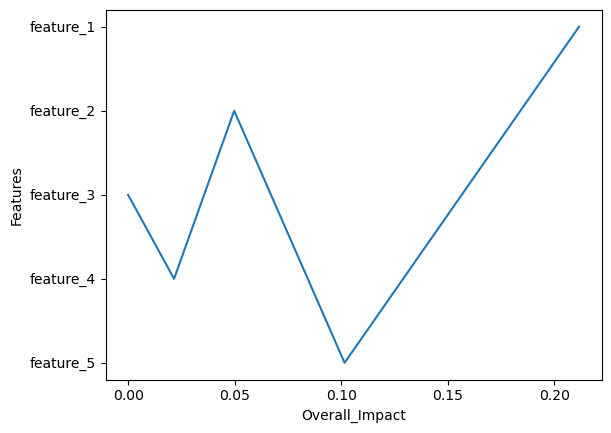

In [31]:
import seaborn as sns
sns.lineplot(data = res, x=res.Overall_Impact.astype(float), y=res.Features, markers='o')

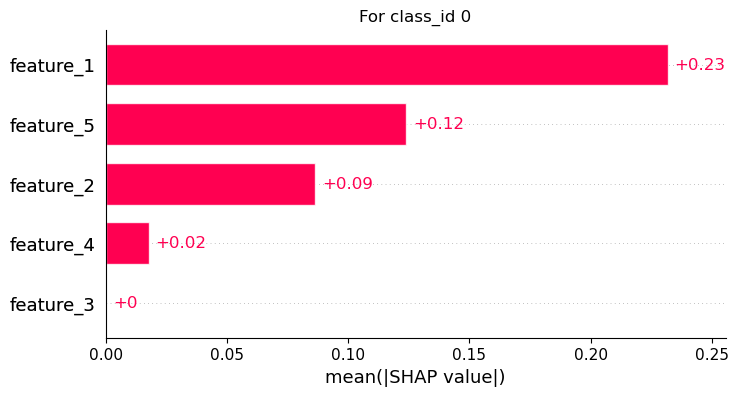

<Figure size 640x480 with 0 Axes>

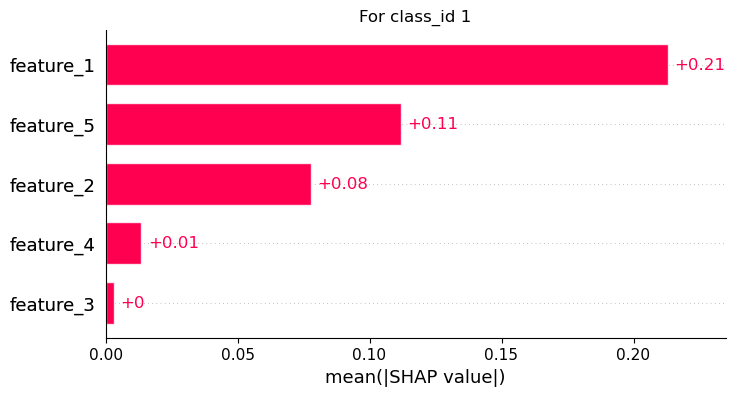

<Figure size 640x480 with 0 Axes>

In [32]:

bar_plot(n_classes=2, shap_values=shap)

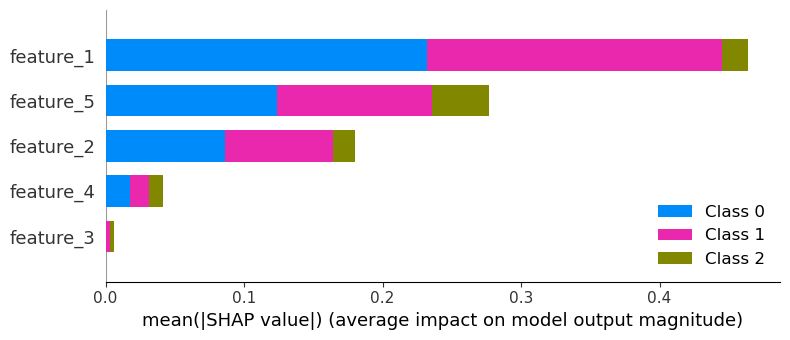

In [33]:
summary_plot(X_test, shap)

In [34]:
n = 4
for i in range(n):
    print(i)

0
1
2
3


In [35]:
if  (
                X_train is not None and 
                X_test is not None and 
                not X_train.empty and 
                not X_test.empty
                ):
    print(True)
else:
    print(False)

True


In [36]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [37]:
shap

.values =
array([[[ 2.11520833e-01, -2.04351521e-01, -7.16931217e-03],
        [ 4.97103175e-02, -3.19556878e-02, -1.77546296e-02],
        [-8.33333333e-05,  2.55555556e-03, -2.47222222e-03],
        [ 2.15049603e-02, -1.00982143e-02, -1.14067460e-02],
        [ 1.01513889e-01, -5.86501323e-02, -4.28637566e-02]],

       [[-1.64383929e-01,  1.26756878e-01,  3.76270503e-02],
        [-6.47817460e-02,  7.60723545e-02, -1.12906085e-02],
        [-5.00000000e-04,  4.32199074e-03, -3.82199074e-03],
        [ 8.24702381e-03, -1.72708333e-02,  9.02380952e-03],
        [-9.44146825e-02,  1.37619610e-01, -4.32049272e-02]],

       [[ 3.19616071e-01, -3.08034722e-01, -1.15813492e-02],
        [ 1.44690476e-01, -1.24857143e-01, -1.98333333e-02],
        [-8.33333333e-05,  2.55555556e-03, -2.47222222e-03],
        [ 2.38462302e-02, -1.32311508e-02, -1.06150794e-02],
        [ 1.76097222e-01, -1.38932540e-01, -3.71646825e-02]]])

.base_values =
array([[0.31583333, 0.6025    , 0.08166667],
       [

In [38]:
orch.auto_explain(shap_values=shap, n_classes=3, model=model)


In [39]:
import shap

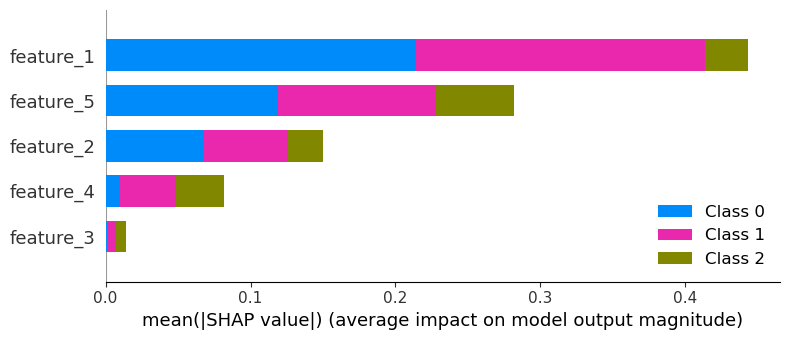

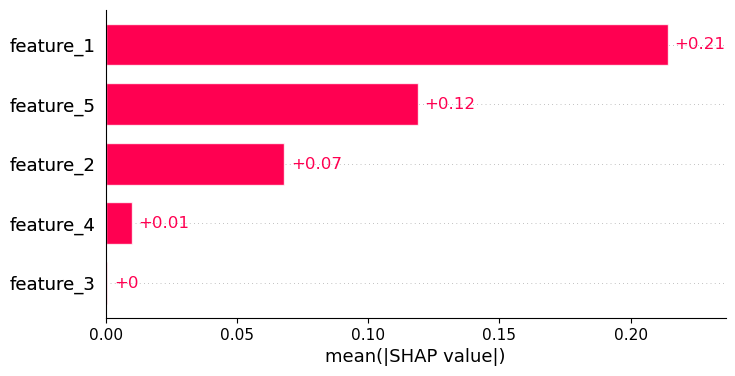

In [40]:
explainer = shap.Explainer(model, X_train)
shap_values_train = explainer(X_train)

shap.summary_plot(shap_values_train, X_train)
shap.plots.bar(shap_values_train[...,0])

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (
                            RandomForestClassifier, RandomForestRegressor,
                            AdaBoostClassifier, AdaBoostRegressor,
                            GradientBoostingClassifier, GradientBoostingRegressor
                            )
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor

In [43]:
import matplotlib.pyplot as plt
from sklearn import tree
import shap
def auto_explain(shap_values, n_classes:int = None, size:tuple|None = None):

        ensembleClassifier_tuple = (RandomForestClassifier, AdaBoostClassifier, XGBClassifier, GradientBoostingClassifier)
        dtree_classifier = DecisionTreeClassifier

        if n_classes is not None and isinstance(n_classes,  float):
            raise ValueError("Provide the number of unique classes in Integer format")
        
        if isinstance(rf, ensembleClassifier_tuple):
            if n_classes is not None:
                for class_id in range(0, n_classes):    
                    plt.title(f"For class_id {class_id}")
                    shap.plots.bar(shap_values[..., class_id])

                if(
                    X_train is not None and X_test is not None and 

                    not X_train.empty and not X_test.empty
                ):

                    plt.title("Summary Plot for X_train")
                    shap.summary_plot(shap_values, X_train)
                    
                    plt.title("Summary Plot for X_test")
                    shap.summary_plot(shap_values, X_test)

            elif n_classes is None:
                plt.title("Global Features Importance")
                shap.plots.bar(shap_values)

            else:
                raise ValueError("X_train or X_test might be None or invalid")
        

        elif isinstance(rf, dtree_classifier):
                plt.figure(figsize=size)
                tree.plot_tree(rf, filled=True, feature_names=X_train.columns, class_names=True)

In [44]:
auto_explain(
    shap_values=shap_values,
    n_classes=2
)

NameError: name 'shap_values' is not defined

NameError: name 'shap_values' is not defined

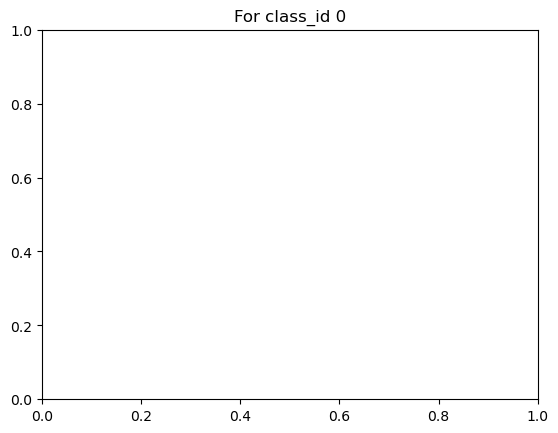

In [45]:
n_classes = 2
for class_id in range(n_classes):    
                    plt.title(f"For class_id {class_id}")
                    shap.plots.bar(shap_values[..., class_id])


In [46]:
len(y_train.value_counts())

3

In [47]:
n_classes= 3
if n_classes != len(y_train.value_counts()):
            raise ValueError("n_classes is either less than or greater than number of classes make sure its exactly equal to n_classes")

In [48]:
from cherrypick.orchestrator import Orchestrator

orch = Orchestrator(train = (X_train, y_train),
                    test = (X_test, y_test),
                    focus_classifier='recall',
                    problem_statement='classification',
                    file_dir='model'
                    )

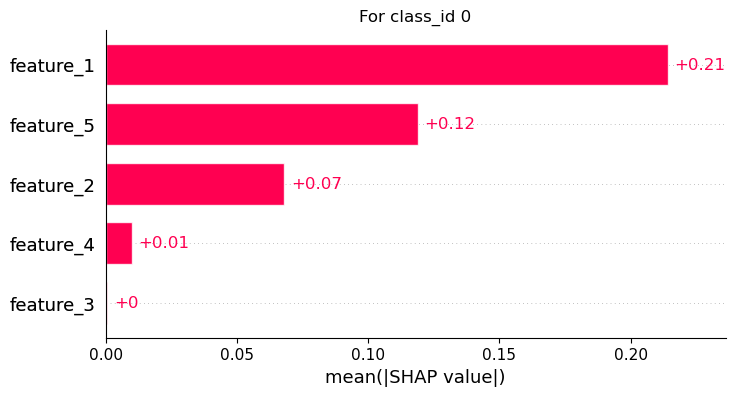

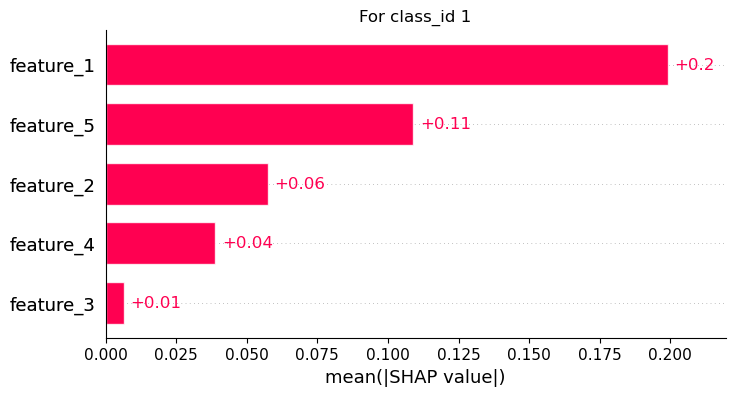

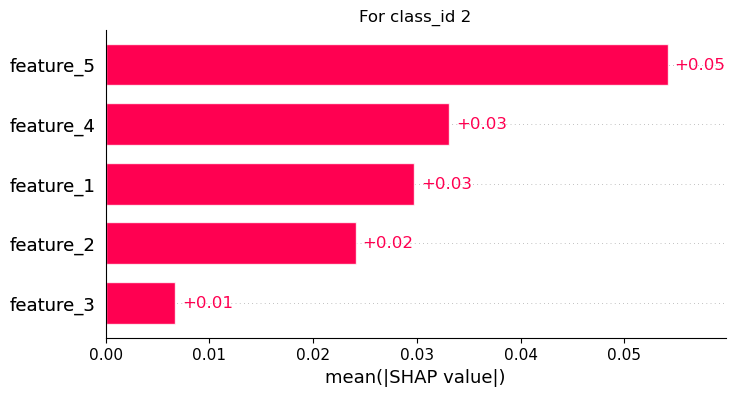

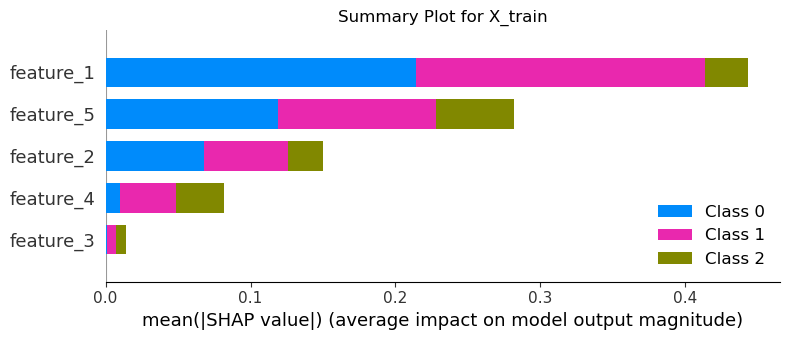

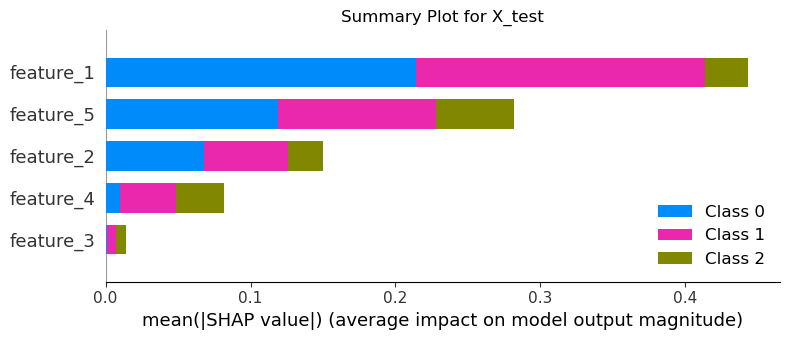

In [49]:
auto_explain(
    shap_values=shap_values_train,
    n_classes=3)

In [ ]:
orch.auto_explain(n_classes=3,
                  shap_values=shap_values_train)

IndexError: list index out of range

In [ ]:
shap

<module 'shap' from 'c:\\Users\\Asus\\anaconda3\\Lib\\site-packages\\shap\\__init__.py'>

In [ ]:
X_test.duplicated

<bound method DataFrame.duplicated of     feature_1  feature_2  feature_3  feature_4  feature_5
9          38        220          1          5         19
11         62        310          1          7         24
0          12        100          1          5         10>

In [ ]:
X_test.corr()

,feature_1,feature_2,feature_3,feature_4,feature_5
feature_1,1.000000,0.998248,NaN,0.854251,0.990161
feature_2,0.998248,1.000000,NaN,0.821995,0.996706
feature_3,NaN,NaN,NaN,NaN,NaN
feature_4,0.854251,0.821995,NaN,1.000000,0.773099
feature_5,0.990161,0.996706,NaN,0.773099,1.000000


In [ ]:
import warnings
warnings.filterwarnings('ignore')
corr = X_test.corr().values
for i in range(len(corr)):
    
    for j in range(i+1, len(corr)):
        print(f'jth : {corr[j]}')

        # if 
  

jth : [0.99824805 1.                nan 0.82199494 0.99670569]
jth : [nan nan nan nan nan]
jth : [0.85425063 0.82199494        nan 1.         0.77309904]
jth : [0.99016079 0.99670569        nan 0.77309904 1.        ]
jth : [nan nan nan nan nan]
jth : [0.85425063 0.82199494        nan 1.         0.77309904]
jth : [0.99016079 0.99670569        nan 0.77309904 1.        ]
jth : [0.85425063 0.82199494        nan 1.         0.77309904]
jth : [0.99016079 0.99670569        nan 0.77309904 1.        ]
jth : [0.99016079 0.99670569        nan 0.77309904 1.        ]


In [ ]:
corr

array([[1.        , 0.99824805,        nan, 0.85425063, 0.99016079],
       [0.99824805, 1.        ,        nan, 0.82199494, 0.99670569],
       [       nan,        nan,        nan,        nan,        nan],
       [0.85425063, 0.82199494,        nan, 1.        , 0.77309904],
       [0.99016079, 0.99670569,        nan, 0.77309904, 1.        ]])

In [ ]:
for i in ["sujal", 'giri']:
    print(i)
    for j in range(2):
        print(f"{j}")

sujal
0
1
giri
0
1


In [ ]:
import numpy as np
matrix = np.ones(shape=(5,5))
matrix

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [ ]:
for i in range(len(corr)):
    print(f'Ith = {corr[i][i]}')
    for j in range(len(corr)):
        print(f'Jth = {corr[j][j]}')

Ith = 1.0
Jth = 1.0
Jth = 1.0
Jth = nan
Jth = 1.0
Jth = 1.0
Ith = 1.0
Jth = 1.0
Jth = 1.0
Jth = nan
Jth = 1.0
Jth = 1.0
Ith = nan
Jth = 1.0
Jth = 1.0
Jth = nan
Jth = 1.0
Jth = 1.0
Ith = 1.0
Jth = 1.0
Jth = 1.0
Jth = nan
Jth = 1.0
Jth = 1.0
Ith = 1.0
Jth = 1.0
Jth = 1.0
Jth = nan
Jth = 1.0
Jth = 1.0


In [ ]:
import shap
from sklearn.ensemble import RandomForestClassifier
explainer = shap.TreeExplainer(RandomForestClassifier().fit(X_train, y_train))
shap_values = explainer(X_train)

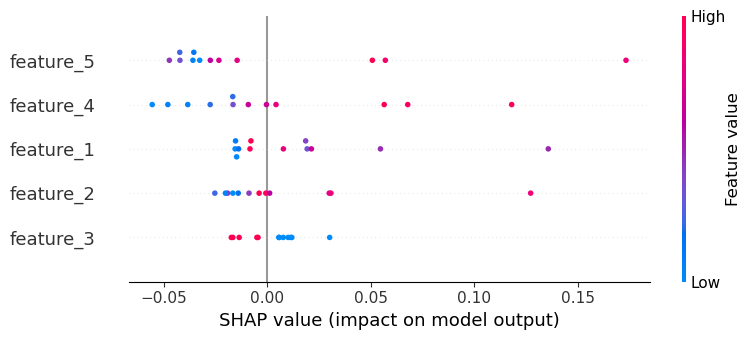

In [ ]:
shap.summary_plot(shap_values[...,2], X_train, plot_type='dot')

In [ ]:
shap.initjs()

shap.plots.force(shap_values[: ,: ,1])

In [ ]:
df = pd.DataFrame({
    "age" : [13, 12, 14, 40, 40, 50 , 1000, 2000]
})


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1)
out = iso.fit_predict(df)
out=np.where(out == -1)[0]
df.drop(index=out)

,age
0,13
1,12
2,14
3,40
4,40
5,50
6,1000


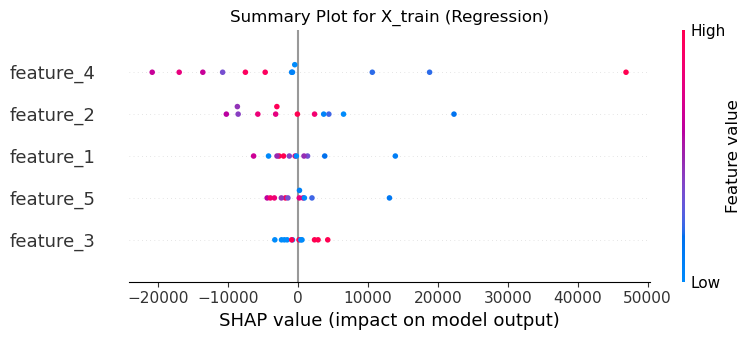

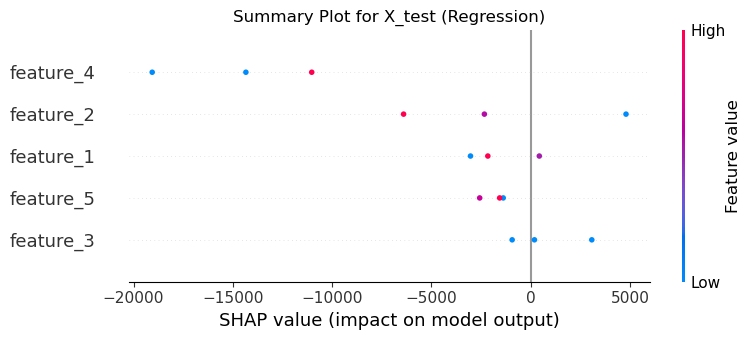

In [7]:
orch.auto_explain()

In [5]:
model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
model = orch.best_estimator
model.predict(X_test)



array([16244.25, 16791.75, 15256.88])

In [2]:
import pandas as pd 
df = pd.DataFrame({
    "age": [1,2,4,6,78]
})
df.shape == (5,1)

True

In [ ]:
not df.empty

True

In [5]:
df[df['age'] > 3]

,age
2,4
3,6
4,78


In [8]:
from cherrypick.anomaly import OutlierPruner
import pandas as pd
def test_anomaly():
    df =  pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 4001, 350, 120, 370, 220, 260, 310, 180, 1000, 1001],
    "feature_3": [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 0]
})

    prune = OutlierPruner(
        method = 'isoforest',
        df=df,
        col = 'feature_2'
    )

    df_pruned = prune.remove_outlier()

    # pruned_data = df_pruned[df_pruned['Feature_2']>1000]

 
    return df_pruned[df_pruned['feature_2'] > 1000].empty, df_pruned

In [9]:
test_anomaly()

(True,
     feature_1  feature_2  feature_3  feature_4  feature_5  target
 0          12        100          1          5         10       1
 1          45        200          1          3         20       2
 2          23        150          1          6         15       0
 4          34        250          1          7         18       1
 6          54        350          1          8         28       1
 8          76        370          1          9         27       2
 9          38        220          1          5         19       1
 10         49        260          0          6         22       2
 11         62        310          1          7         24       1
 12         28        180          0          3         12       1)

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.3)

preds = iso.fit_predict(pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 4001, 350, 120, 370, 220, 260, 310, 180, 1000, 1001],
    "feature_3": [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 0]
}))
preds

array([ 1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1, -1, -1])

In [11]:
import numpy as   np
df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 4001, 350, 120, 370, 220, 260, 310, 180, 1000, 1001],
    "feature_3": [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 0]
})
df.iloc[preds != -1]

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,12,100,1,5,10,1
1,45,200,1,3,20,2
2,23,150,1,6,15,0
4,34,250,1,7,18,1
6,54,350,1,8,28,1
7,21,120,0,4,12,0
9,38,220,1,5,19,1
10,49,260,0,6,22,2
11,62,310,1,7,24,1
12,28,180,0,3,12,1


In [32]:
dtype = (df.select_dtypes(exclude='object')).dtypes

for i in dtype:
    if i == np.int64:
        print(True)
    else:
        False

True
True
True
True
True
True


In [33]:
for dt in dtype:
    print(dt)

int64
int64
int64
int64
int64
int64


In [36]:
if (dtype == np.int64).all():
    print(True)

True


In [ ]:
from cherrypick.preprocessing import Preprocessor
from cherrypick.splits import splitter
def test_labelEncoder():
    df= pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 4200000, 3600000],
   
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : [1200202, 211222, 11333, 32231, 1344, 23232, 11122, 2443, 134442, 33231, 232322, 12121, 55671, 98762, 8760]
})
    preprocess = Preprocessor(
        df=df
    )
    
    
    train, test = splitter(df=df, test_size=0.2, target='target')
    global X_train
    X_train, X_test = preprocess.encoder(train_data=train, test_data=test, column='feature_3', encoder_dir='model', type='onehot')

    
    # return "feature_3_bad" in X_train.columns 
    return ((X_train[['feature_3_bad']].select_dtypes(exclude='object')).all()) ==  np.int64 
    

In [82]:
ans = (X_train.select_dtypes(exclude='object').all()['feature_3_bad'] ) 

X_train['feature_3_bad'].dtype != 'object'

True

In [91]:
(X_train.select_dtypes(exclude='object'))['feature_3_bad'].dtype

dtype('float64')

In [76]:
test_labelEncoder()

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (12, 5)
Independent Feature = (12,)
Test dataset :

Dependent feature = (3, 5)
Independent Feature = (3,)


TypeError: descriptor '__array_wrap__' for 'numpy.generic' objects doesn't apply to a 'numpy.ndarray' object

In [94]:
df= pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 4200000, 3600000],
    "feature_3": ['Bad', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad', 'good', 'bad', 'good', 'bad', 'good', 'bad', 'good'],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : ['b', 'a', 'c', 'b', 'a', 'c', 'a', 'b', 'c', 'a', 'c', 'b', 'a', 'a', 'b']
})
preprocess = Preprocessor(
        df=df
    )
train, test = splitter(df=df, test_size=0.2, target='target')
y_train, y_test = preprocess.encoder(type='label', train_data=train, test_data=test, column='feature_3', encoder_dir='model')

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (12, 5)
Independent Feature = (12,)
Test dataset :

Dependent feature = (3, 5)
Independent Feature = (3,)


In [97]:
y_train.dtype

dtype('int32')

In [101]:
np.issubdtype(y_train.dtype, np.integer)

True

In [2]:
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=5,
    n_informative=3,
    random_state=42
)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [3]:
X

array([[ 0.09699596,  2.09238728,  0.59515703, -1.00601738, -0.81822068],
       [-0.33450124,  1.76545424, -0.47494531,  0.40498171, -0.65332923],
       [-0.60170661, -1.05771093,  1.85227818,  0.82254491, -0.01349722],
       [-0.71435142, -1.1913035 ,  1.86577451,  0.65655361,  0.47383292],
       [ 0.8219025 ,  0.09176078,  0.08704707, -1.98756891, -0.29900735],
       [-0.12791759,  0.20346364, -0.95554044, -0.75635075, -1.60644632],
       [ 0.15039379,  0.95042384,  0.34175598, -0.57690366,  1.87617084],
       [ 0.35778736,  1.05380205,  0.56078453, -1.37766937,  1.08305124],
       [-0.40122047,  0.0976761 ,  0.22409248, -0.77300978,  0.0125924 ],
       [ 0.07409478, -1.70338244,  1.62861555, -0.0555477 , -1.38010146],
       [ 0.22745993,  0.18463386,  1.30714275,  0.25988279, -1.60748323],
       [ 2.06074792,  0.97157095,  1.75534084,  0.64537595, -0.24896415],
       [ 0.78182287,  0.52194157, -1.23695071,  0.29698467, -1.32045661],
       [-1.00252936,  0.32271856, -0.0

In [1]:
from sklearn.model_selection import train_test_split
from cherrypick.orchestrator import Orchestrator
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=5,
    n_informative=3,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

cherry = Orchestrator(
        problem_statement='regression',
        focus_regressor='mse',
        train=(X_train, y_train),
        test=(X_test, y_test),
        file_dir='model'
    )
# model = cherry.best_estimator
# model
cherry.orchestrate()

-------------Demorgraphics-------------
Best Model : LinearRegression
LinearRegression Accuracy(R2 SCore) : 1.0
LinearRegression MSE : 3.2299120903369108e-27
---------------------------------------


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
import pandas as pd


  

0

In [3]:
cherry.topkmodel()
cherry.critique()

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════╤═══════════════════╤════════════════════╤═══════════════════╤════════════════════╗ │
│ ║ Rank │     estimator      │     accuracy      │        mse         │        mae        │        rmse        ║ │
│ ╟──────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┼────────────────────╢ │
│ ║ 🥇1  │ LinearRegression() │        1.0        │ 3.229912090336910… │ 4.40536496171262… │ 5.683231554614778… ║ │
│ ╟──────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┼────────────────────╢ │
│ ║ 🥈2  │ RandomForestRegre… │ 0.87153903367131… │ 499.0404444960838  │ 16.54434729127502 │ 22.33921315749693  ║ │
│ ╟──────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┼────────────────────╢ │
│ ║ 🥉3  │ GradientBoostingR… │ 0.86084892014895… │ 540.5690049325764  │ 16.3496193323762… │ 23.250139890602302 ║ │
│ ╟──────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┼────────────────────╢ │
│ ║  4   │ KNeighborsRegress… │ 0.83722706633992… │ 632.3343151398765  │ 18.0661125377401… │ 25.146258471984982 ║ │
│ ╟──────┼────────────────────┼───────────────────┼────────────────────┼───────────────────┼────────────────────╢ │
│ ║  5   │ XGBRegressor(base… │ 0.81730972153935… │ 709.7084847925314  │ 21.1528755788307… │ 26.640354441946364 ║ │
│ ║      │   booster=None,    │                   │                    │                   │                    ║ │
│ ║      │  callbacks=None,   │                   │                    │                   │                    ║ │
│ ║      │              cols… │                   │                    │                   │                    ║ │
│ ║      │ colsample_bynode=… │                   │                    │                   │                    ║ │
│ ║      │              cols… │                   │                    │                   │                    ║ │
│ ║      │    device=None,    │                   │                    │                   │                    ║ │
│ ║      │ early_stopping_ro… │                   │                    │                   │                    ║ │
│ ║      │              enab… │                   │                    │                   │                    ║ │
│ ║      │ eval_metric=None,  │                   │                    │                   │                    ║ │
│ ║      │ feature_types=Non… │                   │                    │                   │                    ║ │
│ ║      │              feat… │                   │                    │                   │                    ║ │
│ ║      │    gamma=None,     │                   │                    │                   │                    ║ │
│ ║      │ grow_policy=None,  │                   │                    │                   │                    ║ │
│ ║      │              impo… │                   │                    │                   │                    ║ │
│ ║      │ interaction_const… │                   │                    │                   │                    ║ │
│ ║      │              lear… │                   │                    │                   │                    ║ │
│ ║      │   max_bin=None,    │                   │                    │                   │                    ║ │
│ ║      │ max_cat_threshold… │                   │                    │                   │                    ║ │
│ ║      │              max_… │                   │                    │                   │                    ║ │
│ ║      │ max_delta_step=No… │                   │                    │                   │                    ║ │
│ ║      │  max_depth=None,   │                   │        

With Relative Overfitting Gap = -1.0, good to go for predictions!


In [ ]:
import cherrypick as cherry 

cherry.explain.explainer()

In [1]:
from cherrypick import Orchestrator

In [ ]:
from cherrypick.anomaly import OutlierPruner

In [30]:

import pandas as pd
import time
import shap
import numpy as np
import joblib
import logging as log
import matplotlib.pyplot as plt
from typing import Literal, List, Dict
from rich.console import Console
from rich.table import Table
from rich.progress import Progress, SpinnerColumn, BarColumn, TextColumn, TimeElapsedColumn
from rich.panel import Panel
from rich import box
from rich.table import Table
from rich.console import Console
from sklearn import tree
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.decomposition import PCA, TruncatedSVD
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (
                            RandomForestClassifier, RandomForestRegressor,
                            AdaBoostClassifier, AdaBoostRegressor,
                            GradientBoostingClassifier, GradientBoostingRegressor
                            )
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

class Orches:

    """
    Orchestrator class to automate model training, evaluation,
    and selection for regression and classification tasks.

    Parameters
    ----------
    problem_statement : str
        Type of problem based on the dataset. Must be either
        ``'regression'`` or ``'classification'``.

    focus_regressor : str, default='mse'
        Metric used for selecting the best regression estimator.

        - `'mse'` - Mean Squared Error
        - `'mae'` - Mean Absolute Error
        - `'rmse'` - Root Mean Squared Error

    focus_classifier : str, default='f1score'
        Metric used for selecting the best classification estimator.

        - ``'recall'`` - Recall score
        - ``'precision'`` - Precision score
        - ``'f1score'`` - F1 score

    train : tuple
        Training data in the tuple format ``(X_train, y_train)``.

    test : tuple
        Testing data in the tuple format ``(X_test, y_test)``.

    file_dir : str
        Directory where the best estimator will be saved.
        For example, if a folder ``model/`` exists, use ``file_dir='model'``.
    """

    def __init__(self, train: tuple[pd.DataFrame, pd.Series], test:tuple[pd.DataFrame, pd.Series], file_dir:str, problem_statement : Literal['regression', 'classification'], seed:int = 42, focus_classifier: Literal['recall', 'precision', 'f1score'] = 'f1score', focus_regressor:Literal['mse', 'mae', 'rmse'] = 'mse' ):
        self.X_train, self.y_train = train
        self.X_test, self.y_test = test
        self.seed = seed
        self.file_dir = file_dir
        self.problem_statement = problem_statement
        self.focus_classifier = focus_classifier
        self.focus_regressor = focus_regressor

        ##Model data and persistence 
        self.best_model = []
        self.model_data = {}
        self.model_data_classify = {}
        self.SCALER_CONFIG = {}
    
    @property
    def best_estimator(self):
        """
    Returns best performing trained model.

    Returns
    -------
    object
        The estimator with the highest performance based on
        the selected evaluation metric.
        """
        if self.best_model[0]:
            return self.best_model[0]
        else:
            raise ValueError("No model trained yet, use orchestrate(problem_statement : str , focus_classifier: str = 'f1score', focus_regressor:str = 'mse') to access best performing model")

    def __adjusted_r2score(self, r2):
        return 1 - ((1-r2) * (1-len(self.X_train)) / len(self.X_train) - (self.X_train.shape[1]) - 1)  

    def train(self):
        '''
        The function `orchestrate()` triggers the ML-model orchestration by cherry-picking the best estimator.
        '''

        regressor_models = {
            "LinearRegression" : LinearRegression(),
            "RandomForestRegressor" : RandomForestRegressor(),
            "XgBoostRegressor" : XGBRegressor(),
            "SVR" : SVR(),
            "KNeighborsRegressor" : KNeighborsRegressor(),
            "DecisionTreeRegressor" : DecisionTreeRegressor(),
            "AdaboostRegressor": AdaBoostRegressor(),
            "GradientBoostRegressor" : GradientBoostingRegressor()
        }

        classification_models = dict(

            LogisticRegression = LogisticRegression(),
            SVC = SVC(),
            KNeighborsClassifier = KNeighborsClassifier(),
            RandomForestClassifier = RandomForestClassifier(),
            DecisionTreeClassifier = DecisionTreeClassifier(),
            XGBClassifier = XGBClassifier(),
            AdaBoostClassifier = AdaBoostClassifier(),
            GradientBoostingClassifier = GradientBoostingClassifier()

        )
        linear_model_regression = ['LinearRegression', "SVR", "KNeighborsRegressor"] 

        try:
            if self.problem_statement == 'regression':
                for name, model in regressor_models.items():
                    if name not in linear_model_regression:

                        ensemble = model.fit(self.X_train, self.y_train)
                        y_pred = ensemble.predict(self.X_test)

                        accuracy = r2_score(self.y_test, y_pred)
                        mae = mean_absolute_error(self.y_test, y_pred)
                        mse = mean_squared_error(self.y_test, y_pred)
                        rmse = (mse) ** 0.5
                        adj_r2 = self.__adjusted_r2score(r2=accuracy) ## will be soon applying Adjusted R2_score for the penalisation influence of the useless features.

                        result = dict(
                            estimator = ensemble,
                            accuracy = accuracy,
                            mse=mse,
                            mae=mae,
                            rmse = rmse
                        )
                        self.model_data[name] = result
                        

                    else:
                        scaler = StandardScaler()
                        X_train_scaled = scaler.fit_transform(self.X_train)
                        X_test_scaled = scaler.transform(self.X_test)

                        regressor = model.fit(X_train_scaled, self.y_train)
                        y_pred = regressor.predict(X_test_scaled)

                        accuracy = r2_score(self.y_test, y_pred)
                        mae = mean_absolute_error(self.y_test, y_pred)
                        mse = mean_squared_error(self.y_test, y_pred)
                        rmse = (mse) ** 0.5
                        
                        result = dict(
                            estimator = regressor,
                            accuracy = accuracy,
                            mse=mse,
                            mae=mae,
                            rmse = rmse,
                            
                        )
                        model_name = type(regressor).__name__
                            
                        self.SCALER_CONFIG[model_name] = scaler
                        self.model_data[name] = result
                
                        

                if self.focus_regressor == "mse":
                    
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['mse', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__

                    if model_name in linear_model_regression:
                        scaler = self.SCALER_CONFIG[model_name]
                        joblib.dump(scaler,  f'{self.file_dir}/scaler_{model_name}.pkl')
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} MSE : {data_metrics['mse'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model


                elif self.focus_regressor == "mae":
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['mae', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__

                    if model_name in linear_model_regression:
                        scaler = self.SCALER_CONFIG[model_name]
                        joblib.dump(scaler,  f'{self.file_dir}/scaler_{model_name}.pkl')
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} MAE : {data_metrics['mae'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model

                elif self.focus_regressor == "rmse":
                    
                    data_metrics = pd.DataFrame(self.model_data).T.sort_values(by=['rmse', 'accuracy'], ascending=[True, False])
                    best_model = data_metrics['estimator'].iloc[0]
                    model_name = type(best_model).__name__

                    if model_name in linear_model_regression:
                        scaler = self.SCALER_CONFIG[model_name]
                        joblib.dump(scaler,  f'{self.file_dir}/scaler_{model_name}.pkl')
                   
                    self.best_model.append(best_model)
                    joblib.dump(best_model, f'{self.file_dir}/{model_name}.pkl')
                    print("-------------Demorgraphics-------------")
                    print(f"Best Model : {model_name}")
                    print(f"{model_name} Accuracy(R2 SCore) : {data_metrics['accuracy'].iloc[0]}")
                    print(f"{model_name} RMSE : {data_metrics['rmse'].iloc[0]}")
                    print("---------------------------------------")
                    return best_model
        except Exception as error:
            print(error)
            

In [6]:
from cherrypick.preprocessing import Preprocessor
from cherrypick.splits import splitter
import pandas as pd
df= pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 4200000, 3600000],
   
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    "target" : [1, 1, 1, 0, 1, 2, 0, 2, 1, 0, 2, 1, 0, 2, 0]
})
preprocess = Preprocessor(
        df=df
    )
    
    
train, test = splitter(df=df, test_size=0.2, target='target')



_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (12, 4)
Independent Feature = (12,)
Test dataset :

Dependent feature = (3, 4)
Independent Feature = (3,)


In [36]:
orch.train()

-------------Demorgraphics-------------
Best Model : DecisionTreeRegressor
DecisionTreeRegressor Accuracy(R2 SCore) : -0.820602284887038
DecisionTreeRegressor RMSE : 18467.765602079027
---------------------------------------


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [12]:
config = {}
for key, value in list1.items():
    key = key
    value = value
    config[key] = value

print(config)

{'A': 1, 'B': 2, 'c': 3}


In [9]:
from cherrypick import Orchestrator

cherry = Orchestrator(
    train = train,
    test=test,
    problem_statement='classification',
    focus_classifier='f1score',
    file_dir='model'
)

In [10]:
cherry.orchestrate()

-------------Demographics-------------
Best Model : LogisticRegression(f1score)
LogisticRegression Accuracy : 0.6666666666666666
LogisticRegression Precision : 0.4444444444444444
LogisticRegression Recall : 0.6666666666666666
LogisticRegression f1score : 0.5333333333333333
---------------------------------------


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
model = cherry.topkmodel(access_estimator=5)

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════╤════════════════════╤═══════════════════╤════════════════════╤═══════════════════╗ │
│ ║ Rank │     estimator      │      accuracy      │     precision     │       recall       │      f1score      ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥇1  │ LogisticRegressio… │ 0.6666666666666666 │ 0.44444444444444… │ 0.6666666666666666 │ 0.53333333333333… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥈2  │       SVC()        │ 0.6666666666666666 │ 0.44444444444444… │ 0.6666666666666666 │ 0.53333333333333… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥉3  │ KNeighborsClassif… │ 0.6666666666666666 │ 0.44444444444444… │ 0.6666666666666666 │ 0.53333333333333… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  4   │ DecisionTreeClass… │ 0.3333333333333333 │ 0.66666666666666… │ 0.3333333333333333 │ 0.44444444444444… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  5   │ RandomForestClass… │        0.0         │        0.0        │        0.0         │        0.0        ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  6   │ XGBClassifier(bas… │        0.0         │        0.0        │        0.0         │        0.0        ║ │
│ ║      │   booster=None,    │                    │                   │                    │                   ║ │
│ ║      │  callbacks=None,   │                    │                   │                    │                   ║ │
│ ║      │               col… │                    │                   │                    │                   ║ │
│ ║      │ colsample_bynode=… │                    │                   │                    │                   ║ │
│ ║      │               col… │                    │                   │                    │                   ║ │
│ ║      │    device=None,    │                    │                   │                    │                   ║ │
│ ║      │ early_stopping_ro… │                    │                   │                    │                   ║ │
│ ║      │               ena… │                    │                   │                    │                   ║ │
│ ║      │ eval_metric=None,  │                    │                   │                    │                   ║ │
│ ║      │ feature_types=Non… │                    │                   │                    │                   ║ │
│ ║      │               fea… │                    │                   │                    │                   ║ │
│ ║      │    gamma=None,     │                    │                   │                    │                   ║ │
│ ║      │ grow_policy=None,  │                    │                   │                    │                   ║ │
│ ║      │               imp… │                    │                   │                    │                   ║ │
│ ║      │ interaction_const… │                    │                   │                    │                   ║ │
│ ║      │               lea… │                    │                   │                    │                   ║ │
│ ║      │   max_bin=None,    │                    │                   │                    │                   ║ │
│ ║      │ max_cat_threshold… │                    │                   │                    │                   ║ │
│ ║      │               max… │                    │       

In [ ]:

def auto_explain( n_classes:int = None, size:tuple|None = None, model : str = 'best'):
        """
    Generate SHAP-based explanations for trained models.

    Provides automatic model interpretability using SHAP (SHapley Additive Explanations)
    for both regression and classification tasks. Supports TreeExplainer and
    LinearExplainer, along with visualization tools such as summary plots and barplots.

    Parameters
    ----------
    n_classes : int
        Number of unique output classes. Required for classification tasks.

    size : tuple or None, default=None
        Figure size used for resizing Decision Tree visualizations.

    model : str, default='best'
        Specifies which model to explain.
        If set to ``'best'``, the top-performing estimator is used.

    Returns
    -------
    None
        Generates SHAP visualizations such as summary plots and barplots if n_classes is provided for classification task.

    Notes
    -----
    - Uses SHAP TreeExplainer for tree-based models and LinearExplainer for linear models.
    - Supports both regression and classification workflows.
    - Visual outputs include summary plots and feature importance insights.
    """
        
        ensembleClassifier_tuple = (
                                    RandomForestClassifier,
                                    AdaBoostClassifier, 
                                    XGBClassifier, 
                                    GradientBoostingClassifier
                                )
        
        linearClassifier_tuple = (
                                  LogisticRegression, 
                                )
        
        dtree_classifier = DecisionTreeClassifier

        ensembleRegressor_tuple = (
                                   RandomForestRegressor, 
                                   AdaBoostRegressor, 
                                   XGBRegressor, 
                                   GradientBoostingRegressor
                                   )
 

        if model != 'best':
            model = model

        elif model == 'best': 
            model = self.best_model[0]
        else:
            raise ValueError("Model is either not supported or just there is no model that exists")
        

        if self.problem_statement == 'classification':

            if n_classes is not None and isinstance(n_classes,  float):
                raise ValueError("Provide the number of unique classes in Integer format")
            
            if n_classes != len(self.y_train.value_counts()):
                raise ValueError("n_classes is either less than or greater than number of classes make sure its exactly equal to n_classes")
            

            
            if isinstance(model, ensembleClassifier_tuple):
                explainer = shap.TreeExplainer(model, self.X_train)

                shap_values_train = explainer(self.X_train)
                shap_values_test = explainer(self.X_test)

                if n_classes is not None:
                            
                    for class_id in range(n_classes): 
                        plt.figure()   
                        plt.title(f"For class_id {class_id}")
                        shap.plots.bar(shap_values_test[..., class_id])
                        

                    if(
                        self.X_train is not None and self.X_test is not None and 

                        not self.X_train.empty and not self.X_test.empty
                    ):

                        plt.title("Summary Plot for X_train")
                        shap.summary_plot(shap_values_train, self.X_train)
                    

                        
                        plt.title("Summary Plot for X_test")
                        shap.summary_plot(shap_values_test, self.X_test)
                        


                elif n_classes is None:
                    print("bar successful")
                    plt.title("Global Features Importance")
                    shap.plots.bar(shap_values_test)

                else:
                    raise ValueError("X_train or X_test might be None or invalid")
            

            elif isinstance(model, dtree_classifier):
                    plt.figure(figsize=size)
                    tree = tree.plot_tree(self.best_model, filled=True, feature_names=self.X_train.columns, class_names=True)

            
            elif isinstance(model, linearClassifier_tuple):

                explainer = shap.LinearExplainer(model, self.X_train)
                
                shap_values_train = explainer(self.X_train)
                shap_values_test = explainer(self.X_test)

                if n_classes is not None:
                    if len(shap_values_test.shape) >= 3:
                        for class_id in range(0, n_classes):
                            plt.title(f"Class {class_id}")
                            shap.plots.bar(shap_values_test[..., class_id])

                    if(
                        self.X_train is not None and self.X_test is not None and 

                        not self.X_train.empty and not self.X_test.empty
                    ):

                        plt.title("Summary Plot for X_train (Classification)")
                        shap.summary_plot(shap_values_train, self.X_train)
                    
                        plt.title("Summary Plot for X_test (Classification)")
                        shap.summary_plot(shap_values_test, self.X_test) 
                
                elif n_classes is None and len(shap_values_test.shape) == 2:
                    plt.title("Global Feature Imortance (BAR)")
                    shap.plots.bar(shap_values_test)

        if self.problem_statement == 'regression':
            if isinstance(model, ensembleRegressor_tuple):

                explainer = shap.TreeExplainer(model, self.X_train)
                shap_values_test = explainer(self.X_test)  
                shap_values_train = explainer(self.X_train)
                
                plt.title("Summary Plot for X_train (Regression)")
                shap.summary_plot(shap_values_train, self.X_train)

                plt.title("Summary Plot for X_test (Regression)")
                shap.summary_plot(shap_values_test, self.X_test)

        else:
            None

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

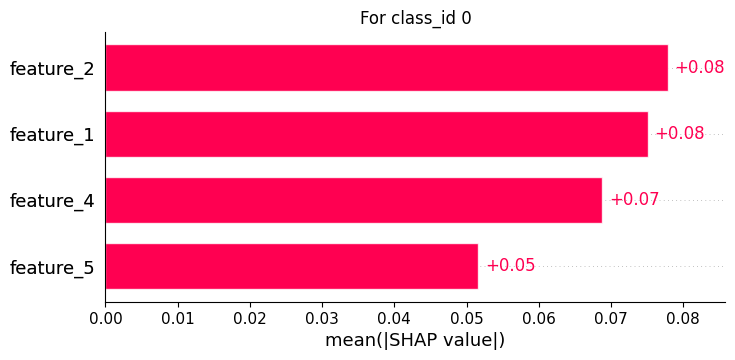

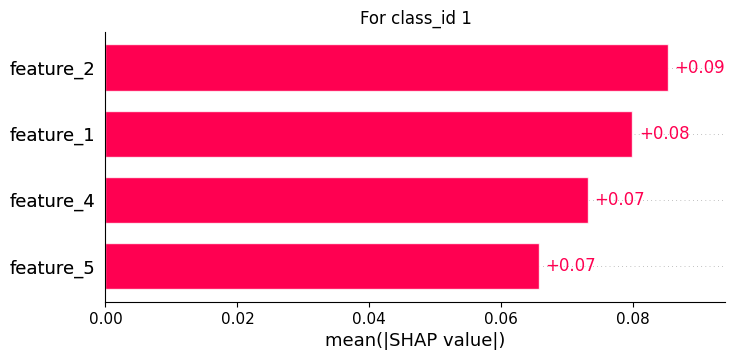

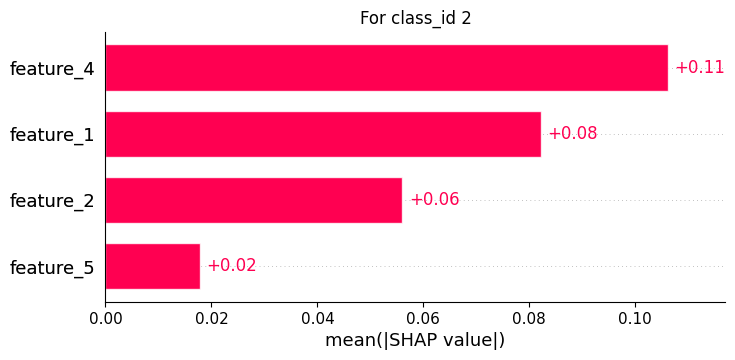

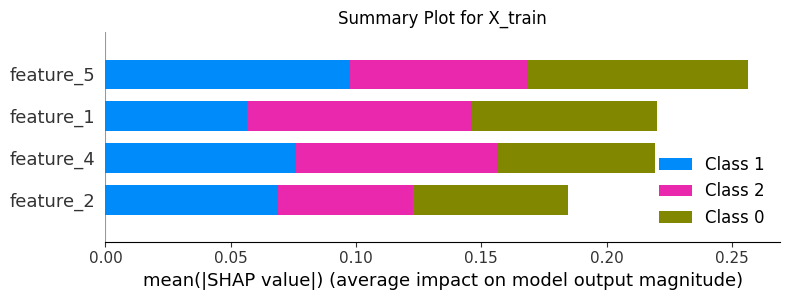

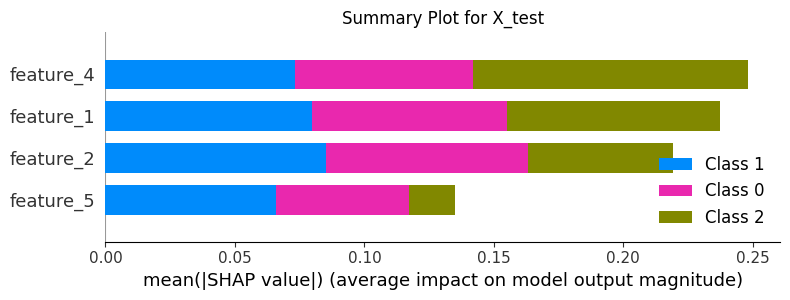

In [15]:
cherry.auto_explain(model=model, n_classes=3)